# Bent crystal channelling — explanatory notebook


## BentChannellingDev element



`BentChannellingDev` is a custom thick Xcoll tracking element designed to model the transverse motion of charged particles undergoing planar channeling in a bent crystal. The element propagates particle coordinates through a crystal of finite length using symplectic integration schemes and a configurable model for the continuum interplanar potential.

The element stores both the crystal geometry and the parameters describing the interplanar potential. Tracking is deterministic and currently does not include stochastic effects such as incoherent scattering or dechanneling.

### Geometry parameters

- **`length`**  
  Crystal length **(m)**.

  Default: `length = 1e-4`


- **`R`**  
Bending radius of the crystal **(m)**.  
This parameter determines the curvature of the crystal planes.

Default: `R = 10.0`


### Material and potential parameters

The current implementation assumes **Silicon (110)** as the default crystal material. The parameters below define the continuum interplanar potential.

- **`U0`**  
Harmonic potential depth used in the harmonic approximation.

Default: `U0 = 21.7681 eV`

- **`Umax`**  
Maximum potential depth used in the Simplified Molière potential.

Default: `Umax = 23.9037 eV`



- **`dp`**  
Interplanar spacing **(m)**.

Default: `dp = 1.92e-10 m`



- **`aTF`**  
Thomas–Fermi screening length **(m)**.

Default: `aTF = 1.94e-11 m`


- **`uT`**  
Thermal vibration amplitude **(m)**.

Default: `uT = 7.5e-12 m`


- **`alpha_i`, `beta_i`**  
Dimensionless parameters used in the Simplified Molière parametrisation.

Defaults: `alpha_i = 0.722452`,
`beta_i = 0.573481`


These parameters can be modified by the user if a different crystal orientation or potential parametrisation is required.

### Physical model selection

Three physical models are currently available:

| Method | Description |
|------|-------------|
| **M2** | Harmonic potential with nonlinear correction |
| **M3** | Extended harmonic potential including bending corrections |
| **M4** | Simplified Molière potential including bending |

The model is selected through:

`method = 2, 3, or 4`


Default: `method = 4`



### Symplectic integrator configuration

Particle propagation inside the crystal is performed using symplectic splitting integrators.

The numerical scheme can be configured through:

- **`order`**

  Allowed values: `order = 2, 4, 6, 8, 10, 12`

  Default: `order = 4`


- **`variant`**

  Splitting variant:

    `variant = 1 → Channel–Kick–Channel`

    `variant = 2 → Kick–Channel–Kick`

    Default: `variant = 1`



### Step selection

The crystal is divided into `n_steps` integration steps.

Two modes are supported:

**Manual mode**
  `n_steps = integer`

**Automatic mode**
  If `n_steps = -1`

the number of steps is estimated automatically from the harmonic oscillation frequency of the potential.

Current default:

- **M2, M3:** ~60 steps per harmonic oscillation period  
- **M4:** ~10 steps per harmonic oscillation period

The internally estimated value is stored in: `_n_steps_auto`







## 1. Necessary Libraries

In [1]:
import os
import time
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xtrack as xt
import xcoll as xc

## 2. Finding Mathematica References

In [2]:
# Path to Mathematica reference solutions
ref_dir = "/home/aniliopo/Documents/different_solutions_-_crystal_potential_new_cases_for_notebook"

if not os.path.isdir(ref_dir):
    raise FileNotFoundError(f"Reference directory not found: {ref_dir}")

ref_files = sorted(glob.glob(os.path.join(ref_dir, "*.csv")))

print(f"Found {len(ref_files)} reference files.")
for f in ref_files[:10]:
    print(os.path.basename(f))

Found 27 reference files.
solution_ET10_L0p0004_R10p.csv
solution_ET10_L0p0004_R1p.csv
solution_ET10_L0p0004_R5p.csv
solution_ET10_L0p001_R10p.csv
solution_ET10_L0p001_R1p.csv
solution_ET10_L0p001_R5p.csv
solution_ET10_L0p01_R10p.csv
solution_ET10_L0p01_R1p.csv
solution_ET10_L0p01_R5p.csv
solution_ET20_L0p0004_R10p.csv


## 3. Loading the cases

In [3]:
# helper function
def load_reference_case(filepath):
    """
    Load a Mathematica reference solution from CSV.

    Expected columns:
        s, x, px
    """
    data = np.loadtxt(filepath, delimiter=",", skiprows=1)

    s_ref = data[:, 0]
    x_ref = data[:, 1]
    px_ref = data[:, 2]

    case_name = os.path.splitext(os.path.basename(filepath))[0]

    return {
        "case_name": case_name,
        "filepath": filepath,
        "s": s_ref,
        "x": x_ref,
        "px": px_ref,
        "x0": x_ref[0],
        "px0": px_ref[0],
        "xF": x_ref[-1],
        "pxF": px_ref[-1],
        "L": s_ref[-1],
    }

In [4]:
# testing
test_file = ref_files[0]

ref_case = load_reference_case(test_file)

print("Loaded case:")
print(f"  case_name = {ref_case['case_name']}")
print(f"  filepath  = {ref_case['filepath']}")
print(f"  L         = {ref_case['L']:.6e} m")
print(f"  x0        = {ref_case['x0']:.6e} m")
print(f"  px0       = {ref_case['px0']:.6e}")
print(f"  xF        = {ref_case['xF']:.6e} m")
print(f"  pxF       = {ref_case['pxF']:.6e}")

Loaded case:
  case_name = solution_ET10_L0p0004_R10p
  filepath  = /home/aniliopo/Documents/different_solutions_-_crystal_potential_new_cases_for_notebook/solution_ET10_L0p0004_R10p.csv
  L         = 4.000000e-04 m
  x0        = -2.000000e-11 m
  px0       = 1.117470e-05
  xF        = 2.673423e-11 m
  pxF       = -1.041747e-05


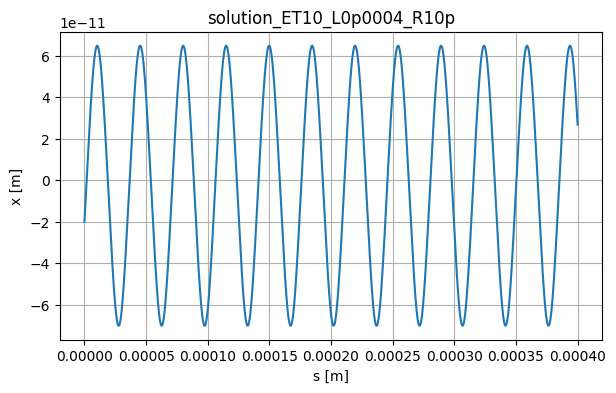

In [5]:
# visual test
plt.figure(figsize=(7, 4))
plt.plot(ref_case["s"], ref_case["x"])
plt.xlabel("s [m]")
plt.ylabel("x [m]")
plt.title(ref_case["case_name"])
plt.grid(True)
plt.show()

## 4. Helper Functions

In [6]:
# relative error calculator
def rel_err(value, reference, floor=1e-30):
    return abs(value - reference) / max(abs(reference), floor)

# transverse energy calculator
def transverse_energy(x, px, bpc, Ux_eV):
    return 0.5 * bpc * px**2 + Ux_eV

# simplified moliere potential calculator
def simplified_moliere_like_potential(x, Un=3.526347, beta_i=0.573481, aTF=0.194e-10):
    return Un * (np.cosh((beta_i / aTF) * x) - 1.0)

# model vs reference calculator
def run_model_on_reference(ref_case, method, order=4, variant=1, n_steps=-1, p0c=150e9, delta=0.0):
    """
    Run one BentChannellingDev model on a given reference case.

    Parameters
    ----------
    ref_case : dict
        Output of load_reference_case(...)
    method : int
        2, 3, or 4
    order : int
        Symplectic integrator order
    variant : int
        1 = Drift-Kick-Drift, 2 = Kick-Drift-Kick
    n_steps : int
        Manual number of integration steps, or -1 for automatic
    p0c : float
        Reference momentum [eV]
    delta : float
        Relative momentum deviation

    Returns
    -------
    result : dict
    """
    x0 = ref_case["x0"]
    px0 = ref_case["px0"]
    L = ref_case["L"]
    xF_ref = ref_case["xF"]
    pxF_ref = ref_case["pxF"]

    crystal = xc.BentChannellingDev(
        length=L,
        method=method,
        order=order,
        variant=variant,
        n_steps=n_steps,
    )

    particle = xt.Particles(
        x=x0,
        px=px0,
        p0c=p0c,
        delta=delta,
    )

    bpc = (
        particle.beta0[0]
        * particle.rvv[0]
        * (1.0 + particle.delta[0])
        * particle.p0c[0]
        * particle.charge_ratio[0]
    )

    Ux0 = simplified_moliere_like_potential(
        x0,
        Un=3.526347,
        beta_i=crystal.beta_i,
        aTF=crystal.aTF
    )
    ET0 = transverse_energy(x0, px0, bpc, Ux0)

    # warm-up
    crystal.track(particle.copy())

    t0 = time.perf_counter()
    crystal.track(particle)
    runtime_s = time.perf_counter() - t0

    result = {
        "case_name": ref_case["case_name"],
        "method": method,
        "order": order,
        "variant": variant,
        "n_steps": int(crystal.n_steps),
        "x0": x0,
        "px0": px0,
        "xF": particle.x[0],
        "pxF": particle.px[0],
        "sF": particle.s[0],
        "xF_ref": xF_ref,
        "pxF_ref": pxF_ref,
        "rel_err_x": rel_err(particle.x[0], xF_ref),
        "rel_err_px": rel_err(particle.px[0], pxF_ref),
        "runtime_ms": runtime_s * 1e3,
        "bpc_eV": bpc,
        "ET0_eV": ET0,
    }

    return result

## 5. Simple Example

### Basic usage of the `BentChannellingDev` element

Before running the full benchmark grid, it is useful to demonstrate the basic usage of the `BentChannellingDev` element on a single reference case.

In the examples below, the three available models are used separately:

- `M2`
- `M3`
- `M4`

For each case, the workflow is the same:

1. load the initial conditions from a reference trajectory,
2. instantiate a `xc.BentChannellingDev` element,
3. create a particle with the same initial coordinates,
4. track the particle through the crystal,
5. compare the final coordinates with the reference final point.

This provides a minimal example of how the element is used in practice.

In [52]:
# Select one reference case for the demonstration
demo_file = ref_files[0]
demo_ref = load_reference_case(demo_file)

print("Selected reference case:")
print(f"  case_name = {demo_ref['case_name']}")
print(f"  L         = {demo_ref['L_target_m']:.6e} m")
print(f"  R         = {demo_ref['R_target_m']:.6e} m")
print(f"  x0        = {demo_ref['x0']:.6e} m")
print(f"  px0       = {demo_ref['px0']:.6e}")
print(f"  xF_ref    = {demo_ref['xF']:.6e} m")
print(f"  pxF_ref   = {demo_ref['pxF']:.6e}")

Selected reference case:
  case_name = solution_ET10_L0p0004_R10p
  L         = 4.000000e-04 m
  R         = 1.000000e+01 m
  x0        = -2.000000e-11 m
  px0       = 1.117470e-05
  xF_ref    = 2.673423e-11 m
  pxF_ref   = -1.041747e-05


In [53]:
def rel_err(value, reference, floor=1e-30):
    return abs(value - reference) / max(abs(reference), floor)

#### Example: `M2`

The first example uses the `M2` model.  
The element is created explicitly with `method=2`, and the particle is tracked using the same initial conditions as the selected reference solution.

In [54]:
crystal_m2 = xc.BentChannellingDev(
    length=demo_ref["L_target_m"],
    R=demo_ref["R_target_m"],
    method=2,
    order=4,
    variant=1,
    n_steps=500,
)

particle_m2 = xt.Particles(
    x=demo_ref["x0"],
    px=demo_ref["px0"],
    p0c=150e9,
    delta=0.0,
)

print("--- M2: BEFORE TRACKING ---")
print(f"x  = {particle_m2.x[0]:.6e}")
print(f"px = {particle_m2.px[0]:.6e}")
print(f"s  = {particle_m2.s[0]:.6e}")

crystal_m2.track(particle_m2.copy())   # warm-up

t0 = time.perf_counter()
crystal_m2.track(particle_m2)
runtime_m2 = (time.perf_counter() - t0) * 1e3

print("\n--- M2: AFTER TRACKING ---")
print(f"x  = {particle_m2.x[0]:.6e}")
print(f"px = {particle_m2.px[0]:.6e}")
print(f"s  = {particle_m2.s[0]:.6e}")

print("\n--- M2: ERRORS W.R.T. REFERENCE ---")
print(f"xF_ref      = {demo_ref['xF']:.6e}")
print(f"pxF_ref     = {demo_ref['pxF']:.6e}")
print(f"rel_err_x   = {rel_err(particle_m2.x[0], demo_ref['xF']):.6e}")
print(f"rel_err_px  = {rel_err(particle_m2.px[0], demo_ref['pxF']):.6e}")
print(f"runtime [ms]= {runtime_m2:.6f}")

--- M2: BEFORE TRACKING ---
x  = -2.000000e-11
px = 1.117470e-05
s  = 0.000000e+00

--- M2: AFTER TRACKING ---
x  = 2.681965e-11
px = -1.041164e-05
s  = 4.000000e-04

--- M2: ERRORS W.R.T. REFERENCE ---
xF_ref      = 2.673423e-11
pxF_ref     = -1.041747e-05
rel_err_x   = 3.195036e-03
rel_err_px  = 5.597506e-04
runtime [ms]= 0.108200


#### Example: `M3`

The second example uses the `M3` model.  
The workflow is identical, but the physical model is changed by setting `method=3`.

In [55]:
crystal_m3 = xc.BentChannellingDev(
    length=demo_ref["L_target_m"],
    R=demo_ref["R_target_m"],
    method=3,
    order=4,
    variant=1,
    n_steps=500,
)

particle_m3 = xt.Particles(
    x=demo_ref["x0"],
    px=demo_ref["px0"],
    p0c=150e9,
    delta=0.0,
)

print("--- M3: BEFORE TRACKING ---")
print(f"x  = {particle_m3.x[0]:.6e}")
print(f"px = {particle_m3.px[0]:.6e}")
print(f"s  = {particle_m3.s[0]:.6e}")

crystal_m3.track(particle_m3.copy())   # warm-up

t0 = time.perf_counter()
crystal_m3.track(particle_m3)
runtime_m3 = (time.perf_counter() - t0) * 1e3

print("\n--- M3: AFTER TRACKING ---")
print(f"x  = {particle_m3.x[0]:.6e}")
print(f"px = {particle_m3.px[0]:.6e}")
print(f"s  = {particle_m3.s[0]:.6e}")

print("\n--- M3: ERRORS W.R.T. REFERENCE ---")
print(f"xF_ref      = {demo_ref['xF']:.6e}")
print(f"pxF_ref     = {demo_ref['pxF']:.6e}")
print(f"rel_err_x   = {rel_err(particle_m3.x[0], demo_ref['xF']):.6e}")
print(f"rel_err_px  = {rel_err(particle_m3.px[0], demo_ref['pxF']):.6e}")
print(f"runtime [ms]= {runtime_m3:.6f}")

--- M3: BEFORE TRACKING ---
x  = -2.000000e-11
px = 1.117470e-05
s  = 0.000000e+00

--- M3: AFTER TRACKING ---
x  = 2.682022e-11
px = -1.041160e-05
s  = 4.000000e-04

--- M3: ERRORS W.R.T. REFERENCE ---
xF_ref      = 2.673423e-11
pxF_ref     = -1.041747e-05
rel_err_x   = 3.216554e-03
rel_err_px  = 5.631952e-04
runtime [ms]= 0.177155


#### Example: `M4`

The third example uses the `M4` model.  
Again, the procedure is identical, but the element is instantiated with `method=4`.

In [81]:
crystal_m4 = xc.BentChannellingDev(
    length=demo_ref["L_target_m"],
    R=demo_ref["R_target_m"],
    method=4,
    order=4,
    variant=1,
    n_steps=65,
)

particle_m4 = xt.Particles(
    x=demo_ref["x0"],
    px=demo_ref["px0"],
    p0c=150e9,
    delta=0.0,
)

print("--- M4: BEFORE TRACKING ---")
print(f"x  = {particle_m4.x[0]:.6e}")
print(f"px = {particle_m4.px[0]:.6e}")
print(f"s  = {particle_m4.s[0]:.6e}")

crystal_m4.track(particle_m4.copy())   # warm-up

t0 = time.perf_counter()
crystal_m4.track(particle_m4)
runtime_m4 = (time.perf_counter() - t0) * 1e3

print("\n--- M4: AFTER TRACKING ---")
print(f"x  = {particle_m4.x[0]:.6e}")
print(f"px = {particle_m4.px[0]:.6e}")
print(f"s  = {particle_m4.s[0]:.6e}")

print("\n--- M4: ERRORS W.R.T. REFERENCE ---")
print(f"xF_ref      = {demo_ref['xF']:.6e}")
print(f"pxF_ref     = {demo_ref['pxF']:.6e}")
print(f"rel_err_x   = {rel_err(particle_m4.x[0], demo_ref['xF']):.6e}")
print(f"rel_err_px  = {rel_err(particle_m4.px[0], demo_ref['pxF']):.6e}")
print(f"runtime [ms]= {runtime_m4:.6f}")

--- M4: BEFORE TRACKING ---
x  = -2.000000e-11
px = 1.117470e-05
s  = 0.000000e+00

--- M4: AFTER TRACKING ---
x  = 2.681067e-11
px = -1.041279e-05
s  = 4.000000e-04

--- M4: ERRORS W.R.T. REFERENCE ---
xF_ref      = 2.673423e-11
pxF_ref     = -1.041747e-05
rel_err_x   = 2.859255e-03
rel_err_px  = 4.490561e-04
runtime [ms]= 0.166909


### Minimal usage example

Before performing the full-grid benchmark, it is useful to illustrate the basic usage of the `BentChannellingDev` element on a single test case.

In the example below, the same initial conditions are tracked through a bent crystal using the three available physical models:

- `M2`: harmonic potential with nonlinear correction,
- `M3`: extended harmonic potential including bending corrections,
- `M4`: Simplified Molière potential including bending.

For each model, the final transverse position, the final transverse momentum, and the runtime are reported. This section is intended only as a minimal demonstration of the element interface and of the model selection mechanism.

In [48]:
example_x0 = -2.0e-11
example_px0 = 1.1174698511235647e-05

example_length = 4.0e-4
example_R = 10.0
example_p0c = 150e9
example_delta = 0.0
example_order = 4
example_variant = 1
example_n_steps = 500

In [49]:
def run_single_demo(method, x0, px0, length, R, p0c=150e9, delta=0.0,
                    order=4, variant=1, n_steps=500):
    crystal = xc.BentChannellingDev(
        length=length,
        R=R,
        method=method,
        order=order,
        variant=variant,
        n_steps=n_steps,
    )

    particle = xt.Particles(
        x=x0,
        px=px0,
        p0c=p0c,
        delta=delta,
    )

    bpc = (
        particle.beta0[0]
        * particle.rvv[0]
        * (1.0 + particle.delta[0])
        * particle.p0c[0]
        * particle.charge_ratio[0]
    )

    # warm-up
    crystal.track(particle.copy())

    t0 = time.perf_counter()
    crystal.track(particle)
    runtime_ms = (time.perf_counter() - t0) * 1e3

    return {
        "method": method,
        "length_m": length,
        "R_m": R,
        "x0_m": x0,
        "px0": px0,
        "xF_m": particle.x[0],
        "pxF": particle.px[0],
        "sF_m": particle.s[0],
        "runtime_ms": runtime_ms,
        "n_steps": n_steps,
        "bpc_eV": bpc,
    }

In [50]:
demo_results = []

for method in [2, 3, 4]:
    res = run_single_demo(
        method=method,
        x0=example_x0,
        px0=example_px0,
        length=example_length,
        R=example_R,
        p0c=example_p0c,
        delta=example_delta,
        order=example_order,
        variant=example_variant,
        n_steps=example_n_steps,
    )
    demo_results.append(res)

df_demo = pd.DataFrame(demo_results)
df_demo["method_label"] = df_demo["method"].map({2: "M2", 3: "M3", 4: "M4"})

df_demo = df_demo[
    [
        "method_label",
        "length_m",
        "R_m",
        "x0_m",
        "px0",
        "xF_m",
        "pxF",
        "sF_m",
        "n_steps",
        "runtime_ms",
    ]
]

df_demo

,method_label,length_m,R_m,x0_m,px0,xF_m,pxF,sF_m,n_steps,runtime_ms
0,M2,0.0004,10.0,-2.000000e-11,0.000011,2.681965e-11,-0.00001,0.0004,500,0.129299
1,M3,0.0004,10.0,-2.000000e-11,0.000011,2.682022e-11,-0.00001,0.0004,500,0.118686
2,M4,0.0004,10.0,-2.000000e-11,0.000011,2.670580e-11,-0.00001,0.0004,500,1.225627


## 6. Full grid set-up

In [7]:
import re

def parse_reference_filename(case_name):
    """
    Parse metadata from filenames of the form:
    solution_ET2_L4p0E-4_R10p0
    """
    pattern = r"solution_ET(?P<ET>\d+)_L(?P<L>[^_]+)_R(?P<R>.+)"
    match = re.match(pattern, case_name)

    if match is None:
        return {
            "ET_eV_target": np.nan,
            "L_target_m": np.nan,
            "R_target_m": np.nan,
        }

    ET_str = match.group("ET")
    L_str = match.group("L").replace("p", ".")
    R_str = match.group("R").replace("p", ".")

    return {
        "ET_eV_target": float(ET_str),
        "L_target_m": float(L_str),
        "R_target_m": float(R_str),
    }

In [8]:
def load_reference_case(filepath):
    """
    Load a Mathematica reference solution from CSV.

    Expected columns:
        s, x, px
    """
    data = np.loadtxt(filepath, delimiter=",", skiprows=1)

    s_ref = data[:, 0]
    x_ref = data[:, 1]
    px_ref = data[:, 2]

    case_name = os.path.splitext(os.path.basename(filepath))[0]
    meta = parse_reference_filename(case_name)

    return {
        "case_name": case_name,
        "filepath": filepath,
        "s": s_ref,
        "x": x_ref,
        "px": px_ref,
        "x0": x_ref[0],
        "px0": px_ref[0],
        "xF": x_ref[-1],
        "pxF": px_ref[-1],
        "L": s_ref[-1],
        "ET_eV_target": meta["ET_eV_target"],
        "L_target_m": meta["L_target_m"],
        "R_target_m": meta["R_target_m"],
    }

In [9]:
# parsing test

ref_case = load_reference_case(ref_files[0])

print(ref_case["case_name"])
print("L from file grid :", ref_case["L_target_m"])
print("L from trajectory:", ref_case["L"])
print("R from filename  :", ref_case["R_target_m"])
print("x0               :", ref_case["x0"])
print("px0              :", ref_case["px0"])

solution_ET10_L0p0004_R10p
L from file grid : 0.0004
L from trajectory: 0.0004
R from filename  : 10.0
x0               : -2e-11
px0              : 1.1174698511235647e-05


In [10]:
def run_model_on_reference(ref_case, method, order=4, variant=1, n_steps=-1, p0c=150e9, delta=0.0):
    """
    Run one BentChannellingDev model on a given reference case.
    """
    x0 = ref_case["x0"]
    px0 = ref_case["px0"]
    L = ref_case["L_target_m"] if np.isfinite(ref_case["L_target_m"]) else ref_case["L"]
    R = ref_case["R_target_m"]
    xF_ref = ref_case["xF"]
    pxF_ref = ref_case["pxF"]

    crystal = xc.BentChannellingDev(
        length=L,
        R=R,
        method=method,
        order=order,
        variant=variant,
        n_steps=n_steps,
    )

    particle = xt.Particles(
        x=x0,
        px=px0,
        p0c=p0c,
        delta=delta,
    )

    bpc = (
        particle.beta0[0]
        * particle.rvv[0]
        * (1.0 + particle.delta[0])
        * particle.p0c[0]
        * particle.charge_ratio[0]
    )

    Ux0 = simplified_moliere_like_potential(
        x0,
        Un=3.526347,
        beta_i=crystal.beta_i,
        aTF=crystal.aTF
    )
    ET0 = transverse_energy(x0, px0, bpc, Ux0)

    # warm-up
    crystal.track(particle.copy())

    t0 = time.perf_counter()
    crystal.track(particle)
    runtime_s = time.perf_counter() - t0

    result = {
        "case_name": ref_case["case_name"],
        "method": method,
        "order": order,
        "variant": variant,
        "n_steps": int(crystal.n_steps),
        "ET_eV_target": ref_case["ET_eV_target"],
        "L_target_m": L,
        "R_target_m": R,
        "x0": x0,
        "px0": px0,
        "xF": particle.x[0],
        "pxF": particle.px[0],
        "sF": particle.s[0],
        "xF_ref": xF_ref,
        "pxF_ref": pxF_ref,
        "rel_err_x": rel_err(particle.x[0], xF_ref),
        "rel_err_px": rel_err(particle.px[0], pxF_ref),
        "runtime_ms": runtime_s * 1e3,
        "bpc_eV": bpc,
        "ET0_eV": ET0,
    }

    return result

In [11]:
# step selection
L_MIN = 1e-4
N_STEPS_MIN = 20

def steps_from_length(L):
    return int(N_STEPS_MIN * (L / L_MIN))

In [12]:
# testing step selection
for L in [1e-4, 1e-3, 1e-2]:
    print(L, steps_from_length(L))

0.0001 20
0.001 200
0.01 2000


### Full-grid benchmark

After validating the workflow on a single benchmark case, the same procedure is now extended to the full parameter grid of Mathematica reference solutions.

For each reference trajectory, the three available physical models (`M2`, `M3`, `M4`) are executed using the same initial conditions and crystal parameters. The benchmark grid spans different values of:

- the target transverse energy \(E_T\),
- the crystal length \(L\),
- and the bending radius \(R\).

The results are collected in a single dataframe, which is then used for summary tables and comparative plots.

## 7. Full grid running

In [13]:
all_results = []
for filepath in ref_files:
    ref_case = load_reference_case(filepath)
    L_val = ref_case["L_target_m"]


    for method in [2, 3, 4]:
        try:
            res = run_model_on_reference(
                ref_case,
                method=method,
                order=4,
                variant=1,
                n_steps=steps_from_length(L_val),
                p0c=150e9,
                delta=0.0,
            )
            all_results.append(res)

        except Exception as exc:
            all_results.append({
                "case_name": ref_case["case_name"],
                "method": method,
                "order": 4,
                "variant": 1,
                "n_steps": np.nan,
                "ET_eV_target": ref_case["ET_eV_target"],
                "L_target_m": ref_case["L_target_m"],
                "R_target_m": ref_case["R_target_m"],
                "x0": ref_case["x0"],
                "px0": ref_case["px0"],
                "xF": np.nan,
                "pxF": np.nan,
                "sF": np.nan,
                "xF_ref": ref_case["xF"],
                "pxF_ref": ref_case["pxF"],
                "rel_err_x": np.nan,
                "rel_err_px": np.nan,
                "runtime_ms": np.nan,
                "bpc_eV": np.nan,
                "ET0_eV": np.nan,
                "error": str(exc),
            })

df_all = pd.DataFrame(all_results)

PENALTY_ERR = 10000.0

df_all["rel_err_x_penalised"] = (
    df_all["rel_err_x"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(PENALTY_ERR)
)

df_all["rel_err_px_penalised"] = (
    df_all["rel_err_px"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(PENALTY_ERR)
)

print(f"Number of result rows: {len(df_all)}")
print(f"Number of unique reference cases: {df_all['case_name'].nunique()}")
df_all.head()

Compiling ContextCpu kernels...


e132bc3ff0f24f98844e942d73c7e5db.c: In function ‘BentChannellingDev_track_local_particle’:
e132bc3ff0f24f98844e942d73c7e5db.c:6433:12: warning: unused variable ‘uT’ [-Wunused-variable]
 6433 |     double uT      = BentChannellingDevData_get_uT(el);
      |            ^~
e132bc3ff0f24f98844e942d73c7e5db.c:6427:12: warning: unused variable ‘U0’ [-Wunused-variable]
 6427 |     double U0      = BentChannellingDevData_get_U0(el);
      |            ^~
e132bc3ff0f24f98844e942d73c7e5db.c: In function ‘BentChannellingDev_track_particles’:
e132bc3ff0f24f98844e942d73c7e5db.c:6253:9: warning: ‘nw’ may be used uninitialized in this function [-Wmaybe-uninitialized]
 6253 |     int nw;
      |         ^~
e132bc3ff0f24f98844e942d73c7e5db.c:6252:19: warning: ‘w’ may be used uninitialized in this function [-Wmaybe-uninitialized]
 6252 |     const double* w;
      |                   ^
e132bc3ff0f24f98844e942d73c7e5db.c:6217:9: warning: ‘nw’ may be used uninitialized in this function [-Wmaybe-uninitiali

Done compiling ContextCpu kernels.
Number of result rows: 81
Number of unique reference cases: 27


,case_name,method,order,variant,n_steps,ET_eV_target,L_target_m,R_target_m,x0,px0,...,sF,xF_ref,pxF_ref,rel_err_x,rel_err_px,runtime_ms,bpc_eV,ET0_eV,rel_err_x_penalised,rel_err_px_penalised
0,solution_ET10_L0p0004_R10p,2,4,1,80,10.0,0.0004,10.0,-2.000000e-11,0.000011,...,0.0004,2.673423e-11,-0.000010,1.074391,0.071371,0.035032,1.499971e+11,9.999817,1.074391,0.071371
1,solution_ET10_L0p0004_R10p,3,4,1,80,10.0,0.0004,10.0,-2.000000e-11,0.000011,...,0.0004,2.673423e-11,-0.000010,0.092623,0.002517,0.023517,1.499971e+11,9.999817,0.092623,0.002517
2,solution_ET10_L0p0004_R10p,4,4,1,80,10.0,0.0004,10.0,-2.000000e-11,0.000011,...,0.0004,2.673423e-11,-0.000010,0.000310,0.000062,0.160563,1.499971e+11,9.999817,0.000310,0.000062
3,solution_ET10_L0p0004_R1p,2,4,1,80,10.0,0.0004,1.0,-2.000000e-11,0.000011,...,0.0004,7.595767e-12,-0.000009,NaN,NaN,0.018863,1.499971e+11,9.999817,10000.000000,10000.000000
4,solution_ET10_L0p0004_R1p,3,4,1,80,10.0,0.0004,1.0,-2.000000e-11,0.000011,...,0.0004,7.595767e-12,-0.000009,NaN,NaN,0.017648,1.499971e+11,9.999817,10000.000000,10000.000000


In [14]:
df_all["method_label"] = df_all["method"].map({2: "M2", 3: "M3", 4: "M4"})

df_all = df_all.sort_values(
    by=["R_target_m", "L_target_m", "ET_eV_target", "method"]
).reset_index(drop=True)

In [15]:
print("Total rows:", len(df_all))
print("Reference cases:", df_all["case_name"].nunique())

print("\nNaN raw errors:")
print("rel_err_x:", df_all["rel_err_x"].isna().sum())
print("rel_err_px:", df_all["rel_err_px"].isna().sum())

print("\nPenalised rows:")
print("rel_err_x_penalised:",
      (df_all["rel_err_x_penalised"] == PENALTY_ERR).sum())

print("rel_err_px_penalised:",
      (df_all["rel_err_px_penalised"] == PENALTY_ERR).sum())

Total rows: 81
Reference cases: 27

NaN raw errors:
rel_err_x: 27
rel_err_px: 27

Penalised rows:
rel_err_x_penalised: 27
rel_err_px_penalised: 27


In [16]:
print("Failed runs per method:")

print(
    df_all.groupby("method")["rel_err_x"]
    .apply(lambda x: x.isna().sum())
)

Failed runs per method:
method
2    12
3    15
4     0
Name: rel_err_x, dtype: int64


In [17]:
method_labels = {2: "M2", 3: "M3", 4: "M4"}
df_all["method_label"] = df_all["method"].map(method_labels)

df_all = df_all.sort_values(
    by=["ET_eV_target", "L_target_m", "R_target_m", "method"]
).reset_index(drop=True)

df_all.head(20)

,case_name,method,order,variant,n_steps,ET_eV_target,L_target_m,R_target_m,x0,px0,...,xF_ref,pxF_ref,rel_err_x,rel_err_px,runtime_ms,bpc_eV,ET0_eV,rel_err_x_penalised,rel_err_px_penalised,method_label
0,solution_ET2_L0p0004_R1p,2,4,1,80,2.0,0.0004,1.0,-2.000000e-11,0.000004,...,-1.392185e-11,3.236080e-06,0.140961,0.119471,0.029321,1.499971e+11,1.999973,0.140961,0.119471,M2
1,solution_ET2_L0p0004_R1p,3,4,1,80,2.0,0.0004,1.0,-2.000000e-11,0.000004,...,-1.392185e-11,3.236080e-06,0.304998,0.376438,0.026271,1.499971e+11,1.999973,0.304998,0.376438,M3
2,solution_ET2_L0p0004_R1p,4,4,1,80,2.0,0.0004,1.0,-2.000000e-11,0.000004,...,-1.392185e-11,3.236080e-06,0.082300,0.072604,0.155984,1.499971e+11,1.999973,0.082300,0.072604,M4
3,solution_ET2_L0p0004_R5p,2,4,1,80,2.0,0.0004,5.0,-2.000000e-11,0.000004,...,-3.260340e-11,-2.850862e-06,0.030288,0.065553,0.022680,1.499971e+11,1.999973,0.030288,0.065553,M2
4,solution_ET2_L0p0004_R5p,3,4,1,80,2.0,0.0004,5.0,-2.000000e-11,0.000004,...,-3.260340e-11,-2.850862e-06,0.049986,0.106009,0.022391,1.499971e+11,1.999973,0.049986,0.106009,M3
5,solution_ET2_L0p0004_R5p,4,4,1,80,2.0,0.0004,5.0,-2.000000e-11,0.000004,...,-3.260340e-11,-2.850862e-06,0.002461,0.005747,0.160584,1.499971e+11,1.999973,0.002461,0.005747,M4
6,solution_ET2_L0p0004_R10p,2,4,1,80,2.0,0.0004,10.0,-2.000000e-11,0.000004,...,-2.136388e-11,-4.152999e-06,0.074504,0.031714,0.025788,1.499971e+11,1.999973,0.074504,0.031714,M2
7,solution_ET2_L0p0004_R10p,3,4,1,80,2.0,0.0004,10.0,-2.000000e-11,0.000004,...,-2.136388e-11,-4.152999e-06,0.084405,0.035594,0.024888,1.499971e+11,1.999973,0.084405,0.035594,M3
8,solution_ET2_L0p0004_R10p,4,4,1,80,2.0,0.0004,10.0,-2.000000e-11,0.000004,...,-2.136388e-11,-4.152999e-06,0.000926,0.000422,0.174855,1.499971e+11,1.999973,0.000926,0.000422,M4
9,solution_ET2_L0p001_R1p,2,4,1,200,2.0,0.0010,1.0,-2.000000e-11,0.000004,...,-8.304643e-12,1.360893e-06,0.354454,0.790805,0.034967,1.499971e+11,1.999973,0.354454,0.790805,M2


In [18]:
summary_cols = [
    "case_name",
    "method_label",
    "ET_eV_target",
    "L_target_m",
    "R_target_m",
    "ET0_eV",
    "n_steps",
    "rel_err_x",
    "rel_err_px",
    "runtime_ms",
]

df_summary = df_all[summary_cols].copy()
df_summary.head(15)

,case_name,method_label,ET_eV_target,L_target_m,R_target_m,ET0_eV,n_steps,rel_err_x,rel_err_px,runtime_ms
0,solution_ET2_L0p0004_R1p,M2,2.0,0.0004,1.0,1.999973,80,0.140961,0.119471,0.029321
1,solution_ET2_L0p0004_R1p,M3,2.0,0.0004,1.0,1.999973,80,0.304998,0.376438,0.026271
2,solution_ET2_L0p0004_R1p,M4,2.0,0.0004,1.0,1.999973,80,0.082300,0.072604,0.155984
3,solution_ET2_L0p0004_R5p,M2,2.0,0.0004,5.0,1.999973,80,0.030288,0.065553,0.022680
4,solution_ET2_L0p0004_R5p,M3,2.0,0.0004,5.0,1.999973,80,0.049986,0.106009,0.022391
5,solution_ET2_L0p0004_R5p,M4,2.0,0.0004,5.0,1.999973,80,0.002461,0.005747,0.160584
6,solution_ET2_L0p0004_R10p,M2,2.0,0.0004,10.0,1.999973,80,0.074504,0.031714,0.025788
7,solution_ET2_L0p0004_R10p,M3,2.0,0.0004,10.0,1.999973,80,0.084405,0.035594,0.024888
8,solution_ET2_L0p0004_R10p,M4,2.0,0.0004,10.0,1.999973,80,0.000926,0.000422,0.174855
9,solution_ET2_L0p001_R1p,M2,2.0,0.0010,1.0,1.999973,200,0.354454,0.790805,0.034967


In [19]:
if "error" in df_all.columns:
    failed = df_all[df_all["error"].notna()].copy()
else:
    failed = pd.DataFrame()

print(f"Failed runs: {len(failed)}")


Failed runs: 0


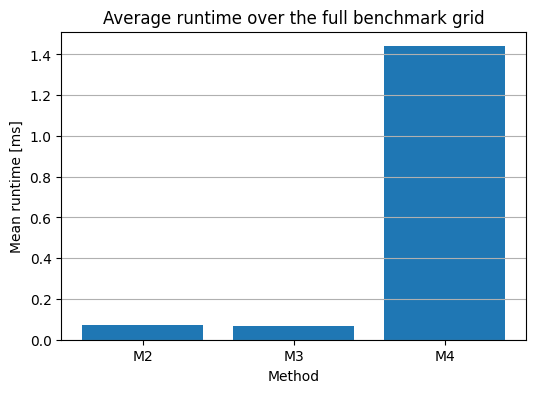

In [21]:
plt.figure(figsize=(6, 4))

runtime_by_method = df_all.groupby("method_label")["runtime_ms"].mean().reindex(["M2", "M3", "M4"])
plt.bar(runtime_by_method.index, runtime_by_method.values)

plt.xlabel("Method")
plt.ylabel("Mean runtime [ms]")
plt.title("Average runtime over the full benchmark grid")
plt.grid(True, axis="y")
plt.show()

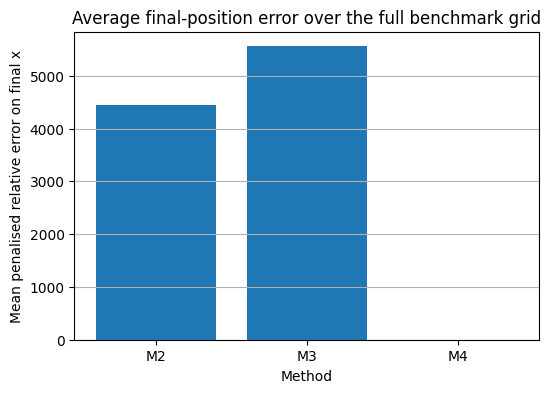

In [22]:
plt.figure(figsize=(6, 4))

err_by_method = (
    df_all.groupby("method_label")["rel_err_x_penalised"]
    .mean()
    .reindex(["M2", "M3", "M4"])
)

plt.bar(err_by_method.index, err_by_method.values)

plt.xlabel("Method")
plt.ylabel("Mean penalised relative error on final x")
plt.title("Average final-position error over the full benchmark grid")
plt.grid(True, axis="y")
plt.show()

In [23]:
all_results = []

for filepath in ref_files:
    ref_case = load_reference_case(filepath)
    L_val = ref_case["L_target_m"]

    for method in [2, 3, 4]:
        try:
            res = run_model_on_reference(
                ref_case,
                method=method,
                order=4,
                variant=1,
                n_steps=steps_from_length(L_val),
                p0c=150e9,
                delta=0.0,
            )
            all_results.append(res)

        except Exception as exc:
            all_results.append({
                "case_name": ref_case["case_name"],
                "method": method,
                "order": 4,
                "variant": 1,
                "n_steps": 500,
                "ET_eV_target": ref_case.get("ET_eV_target", np.nan),
                "L_target_m": ref_case.get("L_target_m", np.nan),
                "R_target_m": ref_case.get("R_target_m", np.nan),
                "x0": ref_case["x0"],
                "px0": ref_case["px0"],
                "xF": np.nan,
                "pxF": np.nan,
                "sF": np.nan,
                "xF_ref": ref_case["xF"],
                "pxF_ref": ref_case["pxF"],
                "rel_err_x": np.nan,
                "rel_err_px": np.nan,
                "runtime_ms": np.nan,
                "bpc_eV": np.nan,
                "ET0_eV": np.nan,
                "error": str(exc),
            })

df_all = pd.DataFrame(all_results)

PENALTY_ERR = 10000.0

df_all["rel_err_x_penalised"] = (
    df_all["rel_err_x"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(PENALTY_ERR)
)

df_all["rel_err_px_penalised"] = (
    df_all["rel_err_px"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(PENALTY_ERR)
)

df_all["method_label"] = df_all["method"].map({2: "M2", 3: "M3", 4: "M4"})

df_all = df_all.sort_values(
    by=["R_target_m", "L_target_m", "ET_eV_target", "method"]
).reset_index(drop=True)

print("rows:", len(df_all))
print("NaN in rel_err_x:", df_all["rel_err_x"].isna().sum())
print("NaN in rel_err_px:", df_all["rel_err_px"].isna().sum())
print("Penalised rows in rel_err_x_penalised:", (df_all["rel_err_x_penalised"] == PENALTY_ERR).sum())
print("Penalised rows in rel_err_px_penalised:", (df_all["rel_err_px_penalised"] == PENALTY_ERR).sum())

df_all.head()

rows: 81
NaN in rel_err_x: 27
NaN in rel_err_px: 27
Penalised rows in rel_err_x_penalised: 27
Penalised rows in rel_err_px_penalised: 27


,case_name,method,order,variant,n_steps,ET_eV_target,L_target_m,R_target_m,x0,px0,...,xF_ref,pxF_ref,rel_err_x,rel_err_px,runtime_ms,bpc_eV,ET0_eV,rel_err_x_penalised,rel_err_px_penalised,method_label
0,solution_ET2_L0p0004_R1p,2,4,1,80,2.0,0.0004,1.0,-2.000000e-11,0.000004,...,-1.392185e-11,0.000003,0.140961,0.119471,0.022500,1.499971e+11,1.999973,0.140961,0.119471,M2
1,solution_ET2_L0p0004_R1p,3,4,1,80,2.0,0.0004,1.0,-2.000000e-11,0.000004,...,-1.392185e-11,0.000003,0.304998,0.376438,0.021959,1.499971e+11,1.999973,0.304998,0.376438,M3
2,solution_ET2_L0p0004_R1p,4,4,1,80,2.0,0.0004,1.0,-2.000000e-11,0.000004,...,-1.392185e-11,0.000003,0.082300,0.072604,0.156861,1.499971e+11,1.999973,0.082300,0.072604,M4
3,solution_ET10_L0p0004_R1p,2,4,1,80,10.0,0.0004,1.0,-2.000000e-11,0.000011,...,7.595767e-12,-0.000009,NaN,NaN,0.027688,1.499971e+11,9.999817,10000.000000,10000.000000,M2
4,solution_ET10_L0p0004_R1p,3,4,1,80,10.0,0.0004,1.0,-2.000000e-11,0.000011,...,7.595767e-12,-0.000009,NaN,NaN,0.023177,1.499971e+11,9.999817,10000.000000,10000.000000,M3


In [24]:
df_last_point = df_all[
    [
        "R_target_m",
        "L_target_m",
        "ET_eV_target",
        "method_label",
        "xF",
        "xF_ref",
        "rel_err_x",
        "pxF",
        "pxF_ref",
        "rel_err_px",
        "runtime_ms",
    ]
].copy()

df_last_point

,R_target_m,L_target_m,ET_eV_target,method_label,xF,xF_ref,rel_err_x,pxF,pxF_ref,rel_err_px,runtime_ms
0,1.0,0.0004,2.0,M2,-1.588429e-11,-1.392185e-11,0.140961,0.000004,0.000003,0.119471,0.022500
1,1.0,0.0004,2.0,M3,-9.675711e-12,-1.392185e-11,0.304998,0.000002,0.000003,0.376438,0.021959
2,1.0,0.0004,2.0,M4,-1.506761e-11,-1.392185e-11,0.082300,0.000003,0.000003,0.072604,0.156861
3,1.0,0.0004,10.0,M2,NaN,7.595767e-12,NaN,NaN,-0.000009,NaN,0.027688
4,1.0,0.0004,10.0,M3,NaN,7.595767e-12,NaN,NaN,-0.000009,NaN,0.023177
...,...,...,...,...,...,...,...,...,...,...,...
76,10.0,0.0100,10.0,M3,5.475309e-11,-6.465776e-11,1.846814,0.000006,0.000005,0.249189,0.260162
77,10.0,0.0100,10.0,M4,-6.314000e-11,-6.465776e-11,0.023474,0.000006,0.000005,0.114639,3.901257
78,10.0,0.0100,20.0,M2,NaN,7.247439e-11,NaN,NaN,-0.000010,NaN,0.081775
79,10.0,0.0100,20.0,M3,NaN,7.247439e-11,NaN,NaN,-0.000010,NaN,0.093727


In [28]:
pivot_x = df_all.pivot_table(
    index=["R_target_m", "L_target_m", "ET_eV_target"],
    columns="method_label",
    values="rel_err_x_penalised"
)

pivot_px = df_all.pivot_table(
    index=["R_target_m", "L_target_m", "ET_eV_target"],
    columns="method_label",
    values="rel_err_px_penalised"
)

pivot_x

method_label                                  M2            M3        M4
R_target_m L_target_m ET_eV_target                                      
1.0        0.0004     2.0               0.140961      0.304998  0.082300
                      10.0          10000.000000  10000.000000  0.518018
                      20.0          10000.000000  10000.000000  0.189691
           0.0010     2.0               0.354454      6.924892  0.176173
                      10.0          10000.000000  10000.000000  1.848926
                      20.0          10000.000000  10000.000000  0.864748
           0.0100     2.0               5.494970      0.536530  2.305384
                      10.0          10000.000000  10000.000000  1.084676
                      20.0          10000.000000  10000.000000  0.324848
5.0        0.0004     2.0               0.030288      0.049986  0.002461
                      10.0              0.328306  10000.000000  0.006112
                      20.0          10000.000000  10000.000000  0.012749
           0.0010     2.0               0.028552      0.063584  0.001559
                      10.0              2.090819  10000.000000  0.010656
                      20.0          10000.000000  10000.000000  0.004017
           0.0100     2.0               1.189071      0.362802  0.173269
                      10.0              6.765397  10000.000000  0.479237
                      20.0          10000.000000  10000.000000  0.004841
10.0       0.0004     2.0               0.074504      0.084405  0.000926
                      10.0              1.074391      0.092623  0.000310
                      20.0          10000.000000  10000.000000  0.000753
           0.0010     2.0               0.221668      0.261547  0.002501
                      10.0              2.251639      1.599006  0.005275
                      20.0          10000.000000  10000.000000  0.000381
           0.0100     2.0               0.171355      0.049514  0.016499
                      10.0              2.027483      1.846814  0.023474
                      20.0          10000.000000  10000.000000  0.007613

In [36]:
df_RL_summary = (
    df_all.groupby(["R_target_m", "L_target_m", "method_label"])[["rel_err_x_penalised", "rel_err_px_penalised", "runtime_ms"]]
    .mean()
    .reset_index()
)


df_RL_summary.to_csv("notebook_results/RL_summary.csv", index=False)

df_RL_summary

,R_target_m,L_target_m,method_label,rel_err_x_penalised,rel_err_px_penalised,runtime_ms
0,1.0,0.0004,M2,6666.713654,6666.706490,0.023032
1,1.0,0.0004,M3,6666.768333,6666.792146,0.021094
2,1.0,0.0004,M4,0.263336,0.094019,0.172097
3,1.0,0.0010,M2,6666.784818,6666.930268,0.027489
4,1.0,0.0010,M3,6668.974964,6666.823972,0.029108
5,1.0,0.0010,M4,0.963283,0.222201,0.413042
6,1.0,0.0100,M2,6668.498323,6668.289341,0.124408
7,1.0,0.0100,M3,6666.845510,6667.115424,0.134312
8,1.0,0.0100,M4,1.238302,6.204769,3.714134
9,5.0,0.0004,M2,3333.452865,3333.390536,0.022837


In [39]:
pivot_x = df_RL_summary.pivot_table(
    index=["R_target_m","L_target_m"],
    columns="method_label",
    values="rel_err_x_penalised"
)

pivot_x.to_csv("notebook_results/RL_error_x_pivot.csv")
pivot_x 

method_label                    M2           M3        M4
R_target_m L_target_m                                    
1.0        0.0004      6666.713654  6666.768333  0.263336
           0.0010      6666.784818  6668.974964  0.963283
           0.0100      6668.498323  6666.845510  1.238302
5.0        0.0004      3333.452865  6666.683329  0.007107
           0.0010      3334.039790  6666.687861  0.005411
           0.0100      3335.984823  6666.787601  0.219115
10.0       0.0004      3333.716298  3333.392343  0.000663
           0.0010      3334.157769  3333.953517  0.002719
           0.0100      3334.066279  3333.965443  0.015862

In [40]:
pivot_px = df_RL_summary.pivot_table(
    index=["R_target_m","L_target_m"],
    columns="method_label",
    values="rel_err_px_penalised"
)

pivot_px.to_csv("notebook_results/RL_error_px_pivot.csv")
pivot_px

method_label                    M2           M3        M4
R_target_m L_target_m                                    
1.0        0.0004      6666.706490  6666.792146  0.094019
           0.0010      6666.930268  6666.823972  0.222201
           0.0100      6668.289341  6667.115424  6.204769
5.0        0.0004      3333.390536  6666.702003  0.002557
           0.0010      3334.295546  6667.333079  0.035902
           0.0100      3333.912748  6667.303621  0.253184
10.0       0.0004      3333.367695  3333.346037  0.000167
           0.0010      3333.579366  3334.109559  0.003066
           0.0100      3334.357864  3334.096810  0.049124

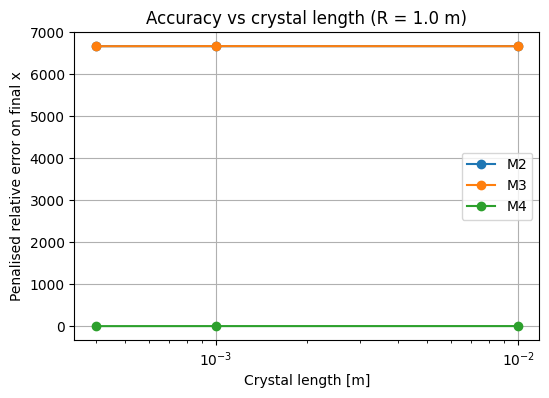

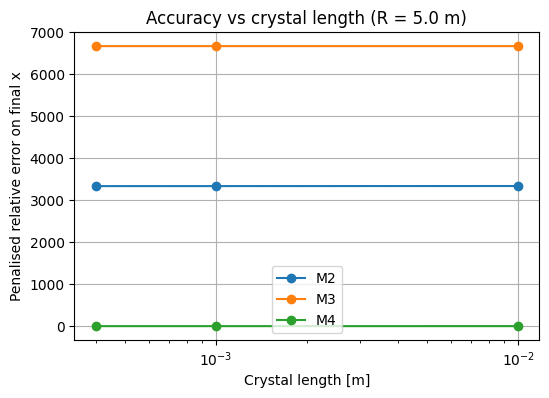

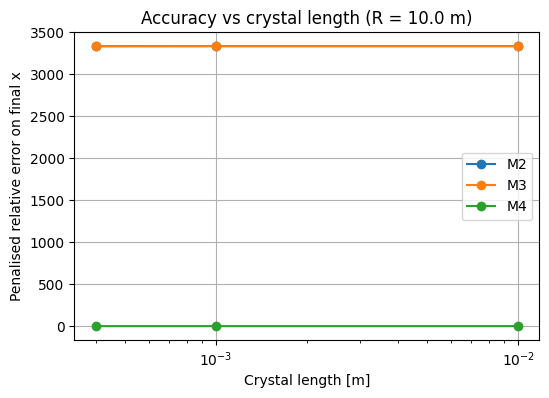

In [41]:
for R_val in sorted(df_RL_summary["R_target_m"].unique()):

    sub = df_RL_summary[df_RL_summary["R_target_m"] == R_val]

    plt.figure(figsize=(6,4))

    for method in ["M2","M3","M4"]:

        sub_m = sub[sub["method_label"] == method].sort_values("L_target_m")

        plt.plot(
            sub_m["L_target_m"],
            sub_m["rel_err_x_penalised"],
            marker="o",
            label=method
        )

    plt.xlabel("Crystal length [m]")
    plt.ylabel("Penalised relative error on final x")
    plt.title(f"Accuracy vs crystal length (R = {R_val} m)")
    plt.xscale("log")
    plt.grid(True)
    plt.legend()

    plt.show()

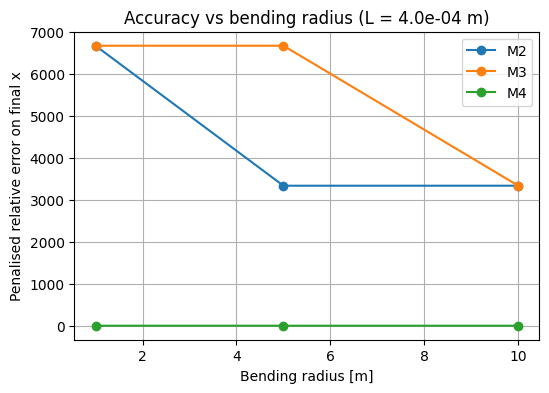

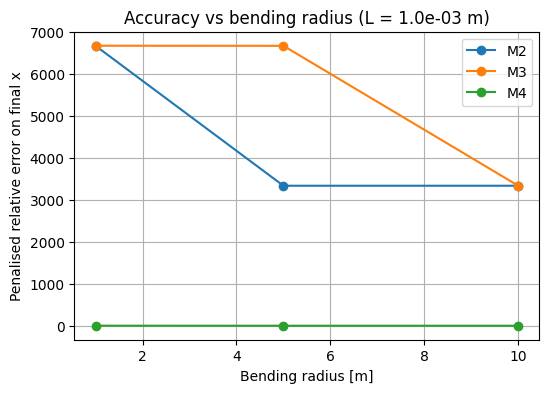

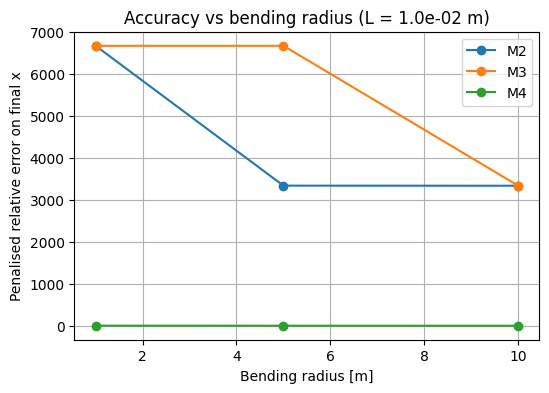

In [42]:
for L_val in sorted(df_RL_summary["L_target_m"].unique()):

    sub = df_RL_summary[df_RL_summary["L_target_m"] == L_val]

    plt.figure(figsize=(6,4))

    for method in ["M2","M3","M4"]:

        sub_m = sub[sub["method_label"] == method].sort_values("R_target_m")

        plt.plot(
            sub_m["R_target_m"],
            sub_m["rel_err_x_penalised"],
            marker="o",
            label=method
        )

    plt.xlabel("Bending radius [m]")
    plt.ylabel("Penalised relative error on final x")
    plt.title(f"Accuracy vs bending radius (L = {L_val:.1e} m)")
    plt.grid(True)
    plt.legend()

    plt.show()

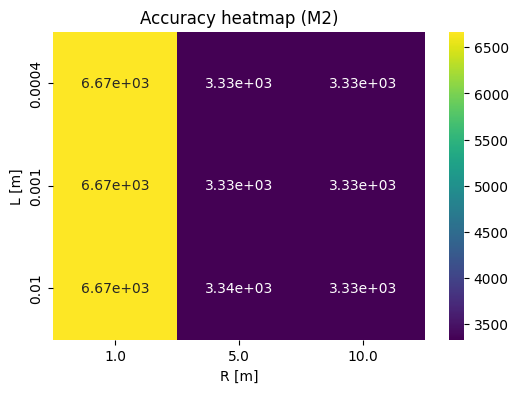

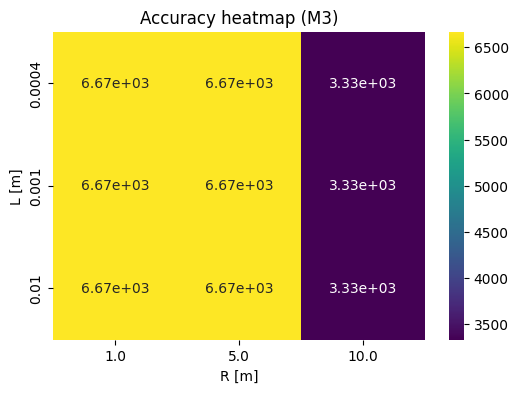

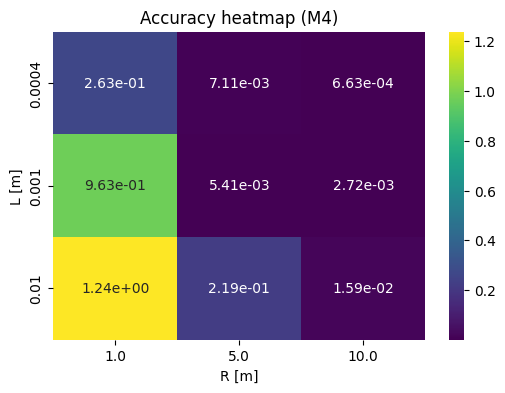

In [43]:
import seaborn as sns

for method in ["M2","M3","M4"]:

    sub = df_RL_summary[df_RL_summary["method_label"] == method]

    heat = sub.pivot_table(
        index="L_target_m",
        columns="R_target_m",
        values="rel_err_x_penalised"
    )

    plt.figure(figsize=(6,4))

    sns.heatmap(
        heat,
        annot=True,
        fmt=".2e",
        cmap="viridis"
    )

    plt.title(f"Accuracy heatmap ({method})")
    plt.xlabel("R [m]")
    plt.ylabel("L [m]")

    plt.show()

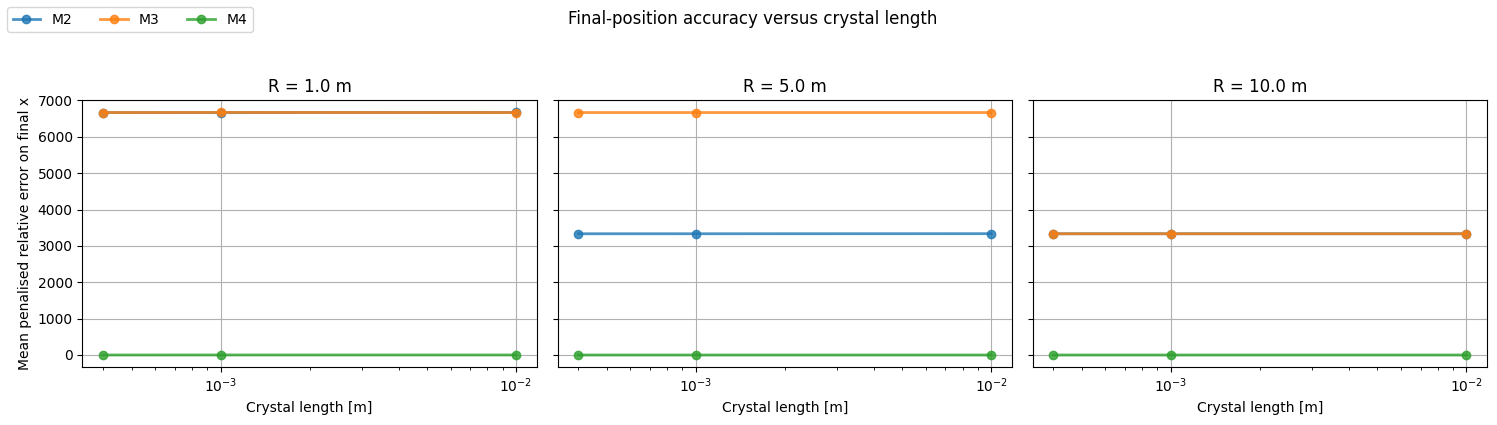

In [45]:
R_values = sorted(df_RL_summary["R_target_m"].unique())

fig, axes = plt.subplots(1, len(R_values), figsize=(5 * len(R_values), 4), sharey=True)

if len(R_values) == 1:
    axes = [axes]

for ax, R_val in zip(axes, R_values):
    sub = df_RL_summary[df_RL_summary["R_target_m"] == R_val].copy()

    for method in ["M2", "M3", "M4"]:
        sub_m = sub[sub["method_label"] == method].sort_values("L_target_m")

        ax.plot(
            sub_m["L_target_m"],
            sub_m["rel_err_x_penalised"],
            marker="o",
            linewidth=2,
            alpha=0.8,
            label=method
        )

    ax.set_xscale("log")
    ax.set_xlabel("Crystal length [m]")
    ax.set_title(f"R = {R_val:.1f} m")
    ax.grid(True)

axes[0].set_ylabel("Mean penalised relative error on final x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=3)

fig.suptitle("Final-position accuracy versus crystal length", y=1.05)
fig.tight_layout()
plt.show()

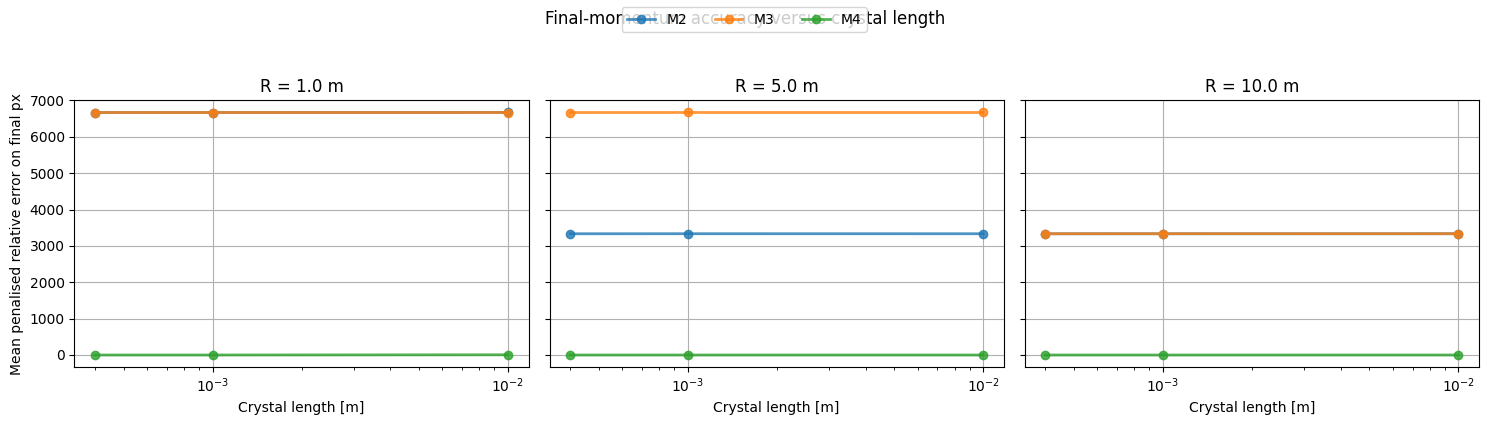

In [46]:
R_values = sorted(df_RL_summary["R_target_m"].unique())

fig, axes = plt.subplots(1, len(R_values), figsize=(5 * len(R_values), 4), sharey=True)

if len(R_values) == 1:
    axes = [axes]

for ax, R_val in zip(axes, R_values):
    sub = df_RL_summary[df_RL_summary["R_target_m"] == R_val].copy()

    for method in ["M2", "M3", "M4"]:
        sub_m = sub[sub["method_label"] == method].sort_values("L_target_m")

        ax.plot(
            sub_m["L_target_m"],
            sub_m["rel_err_px_penalised"],
            marker="o",
            linewidth=2,
            alpha=0.8,
            label=method
        )

    ax.set_xscale("log")
    ax.set_xlabel("Crystal length [m]")
    ax.set_title(f"R = {R_val:.1f} m")
    ax.grid(True)

axes[0].set_ylabel("Mean penalised relative error on final px")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

fig.suptitle("Final-momentum accuracy versus crystal length", y=1.05)
fig.tight_layout()
plt.show()

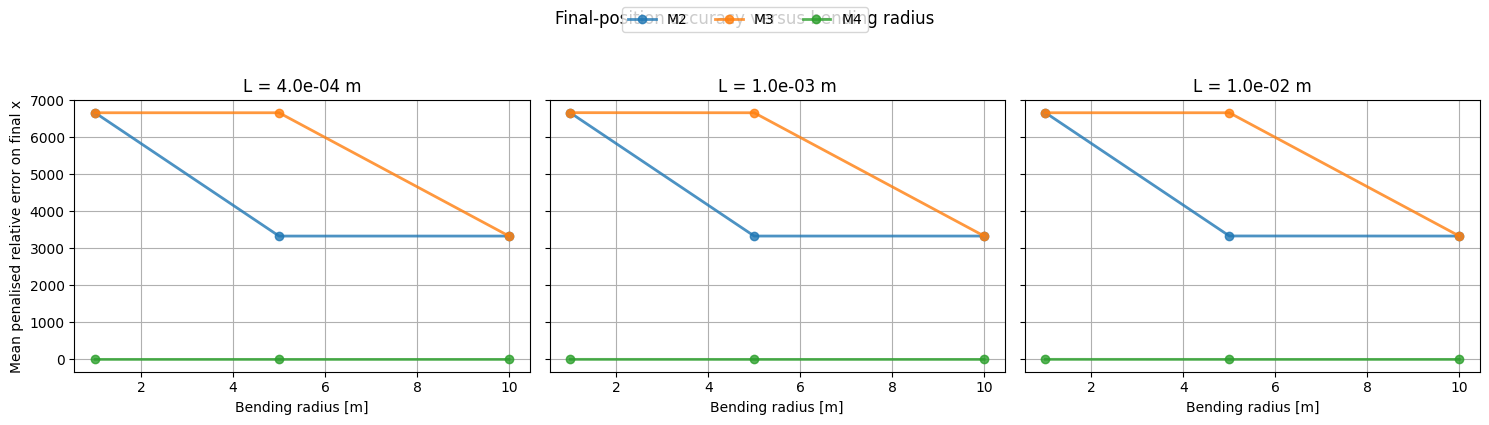

In [47]:
L_values = sorted(df_RL_summary["L_target_m"].unique())

fig, axes = plt.subplots(1, len(L_values), figsize=(5 * len(L_values), 4), sharey=True)

if len(L_values) == 1:
    axes = [axes]

for ax, L_val in zip(axes, L_values):
    sub = df_RL_summary[df_RL_summary["L_target_m"] == L_val].copy()

    for method in ["M2", "M3", "M4"]:
        sub_m = sub[sub["method_label"] == method].sort_values("R_target_m")

        ax.plot(
            sub_m["R_target_m"],
            sub_m["rel_err_x_penalised"],
            marker="o",
            linewidth=2,
            alpha=0.8,
            label=method
        )

    ax.set_xlabel("Bending radius [m]")
    ax.set_title(f"L = {L_val:.1e} m")
    ax.grid(True)

axes[0].set_ylabel("Mean penalised relative error on final x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

fig.suptitle("Final-position accuracy versus bending radius", y=1.05)
fig.tight_layout()
plt.show()

In [30]:
pivot_RL_x = df_RL_summary.pivot_table(
    index=["R_target_m", "L_target_m"],
    columns="method_label",
    values="rel_err_x_penalised"
)

pivot_RL_px = df_RL_summary.pivot_table(
    index=["R_target_m", "L_target_m"],
    columns="method_label",
    values="rel_err_px_penalised"
)

pivot_RL_x

method_label                    M2           M3        M4
R_target_m L_target_m                                    
1.0        0.0004      6666.713654  6666.768333  0.263336
           0.0010      6666.784818  6668.974964  0.963283
           0.0100      6668.498323  6666.845510  1.238302
5.0        0.0004      3333.452865  6666.683329  0.007107
           0.0010      3334.039790  6666.687861  0.005411
           0.0100      3335.984823  6666.787601  0.219115
10.0       0.0004      3333.716298  3333.392343  0.000663
           0.0010      3334.157769  3333.953517  0.002719
           0.0100      3334.066279  3333.965443  0.015862

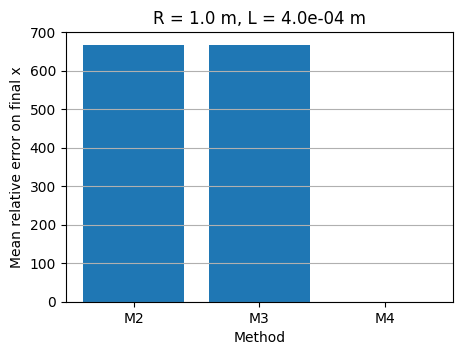

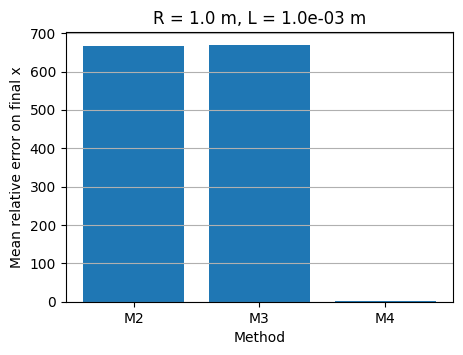

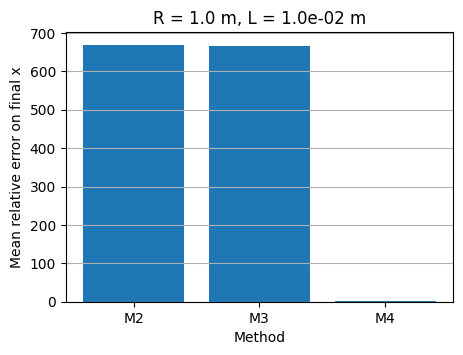

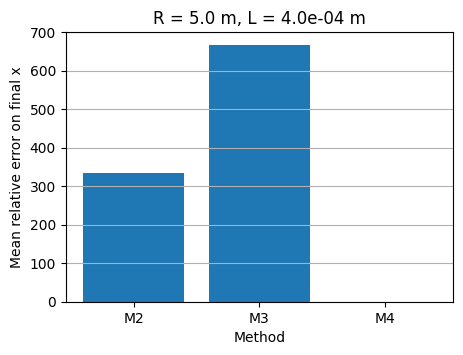

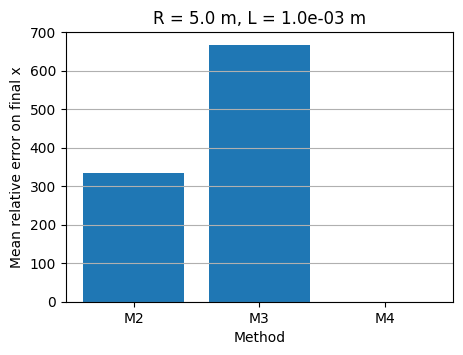

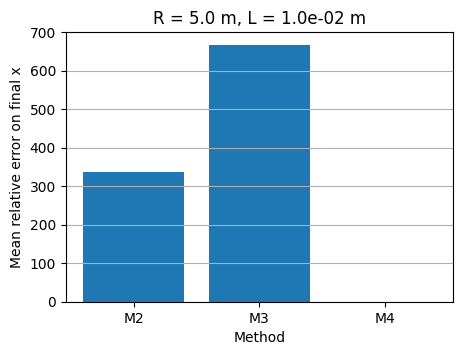

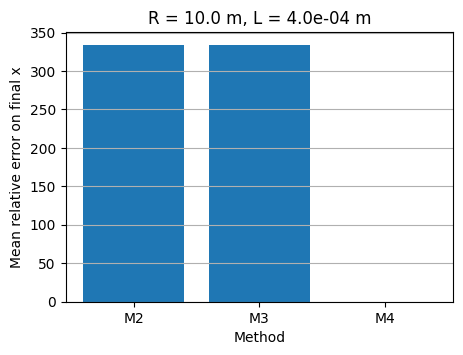

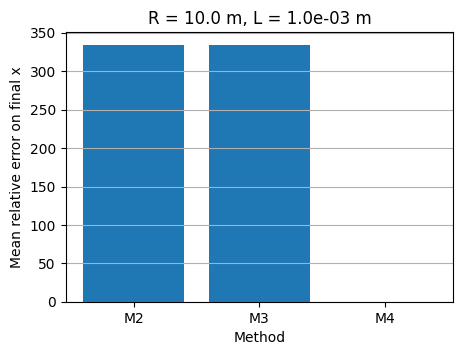

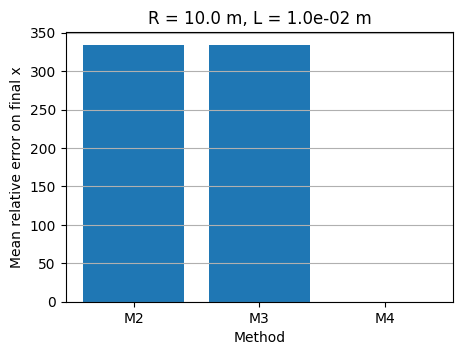

In [31]:
RL_pairs = (
    df_all[["R_target_m", "L_target_m"]]
    .drop_duplicates()
    .sort_values(["R_target_m", "L_target_m"])
    .values
)

for R_val, L_val in RL_pairs:
    sub = df_all[
        (df_all["R_target_m"] == R_val) &
        (df_all["L_target_m"] == L_val)
    ].copy()

    sub["rel_err_x_penalised"] = sub["rel_err_x"].fillna(1000.0)

    summary = (
        sub.groupby("method_label")["rel_err_x_penalised"]
        .mean()
        .reindex(["M2", "M3", "M4"])
    )

    plt.figure(figsize=(5, 3.5))
    plt.bar(summary.index, summary.values)
    plt.xlabel("Method")
    plt.ylabel("Mean relative error on final x")
    plt.title(f"R = {R_val:.1f} m, L = {L_val:.1e} m")
    plt.grid(True, axis="y")
    plt.show()

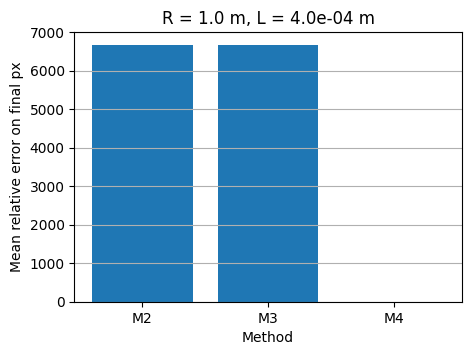

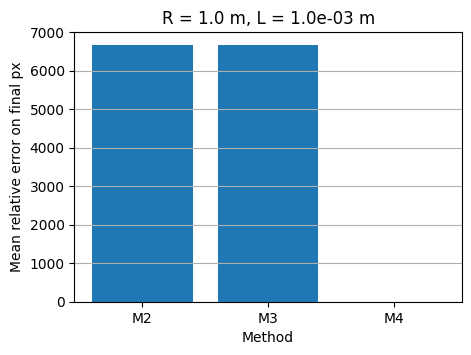

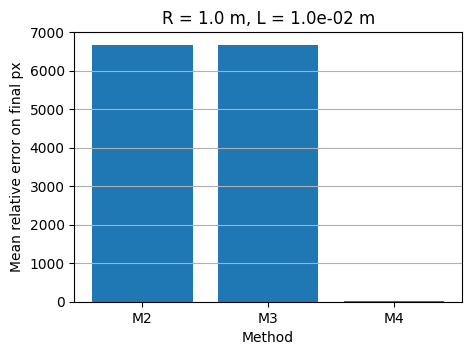

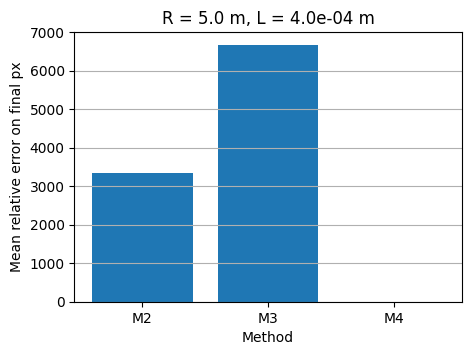

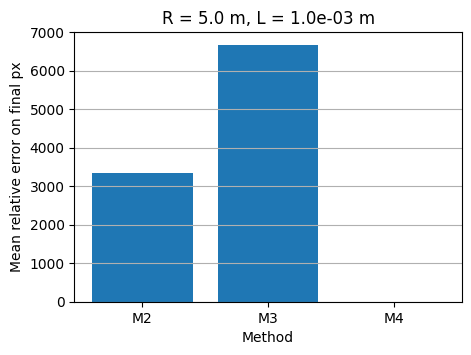

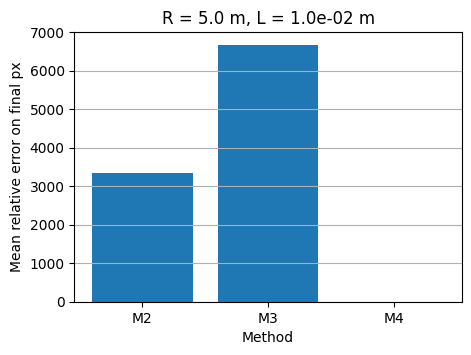

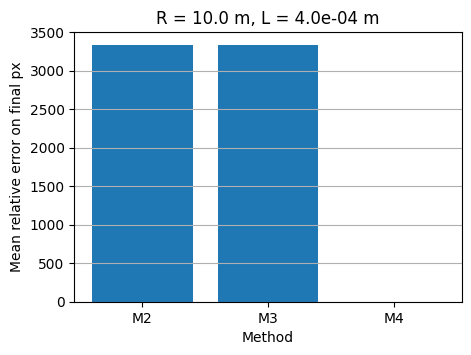

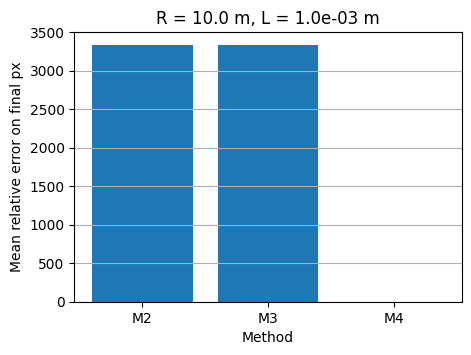

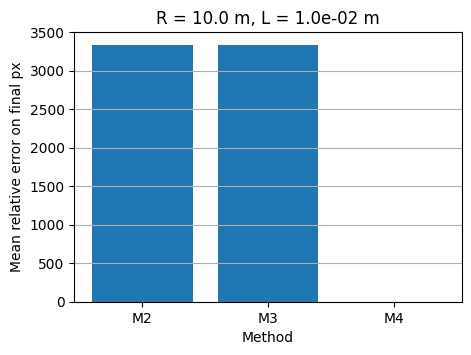

In [32]:
for R_val, L_val in RL_pairs:
    sub = df_all[
        (df_all["R_target_m"] == R_val) &
        (df_all["L_target_m"] == L_val)
    ].copy()

    summary = sub.groupby("method_label")["rel_err_px_penalised"].mean().reindex(["M2", "M3", "M4"])

    plt.figure(figsize=(5, 3.5))
    plt.bar(summary.index, summary.values)
    plt.xlabel("Method")
    plt.ylabel("Mean relative error on final px")
    plt.title(f"R = {R_val:.1f} m, L = {L_val:.1e} m")
    plt.grid(True, axis="y")
    plt.show()

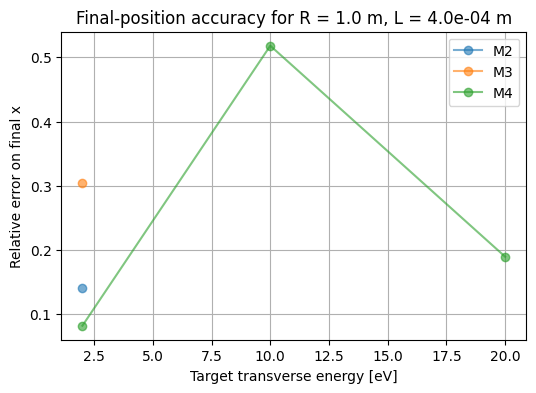

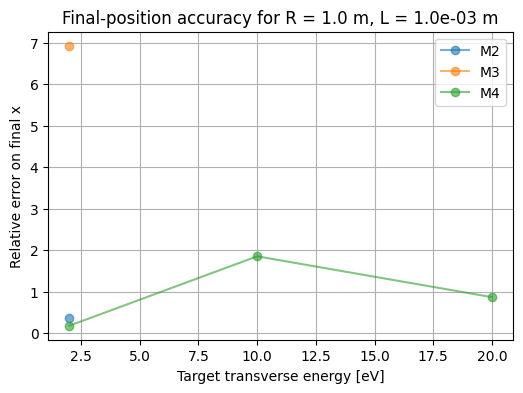

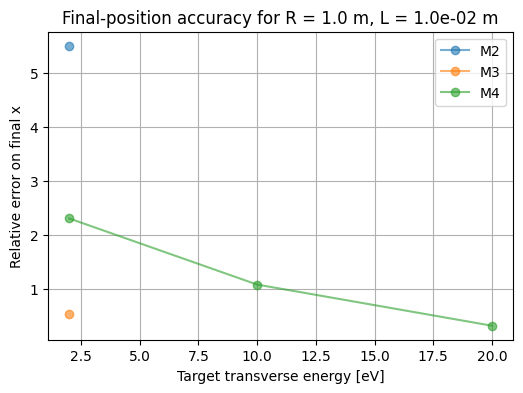

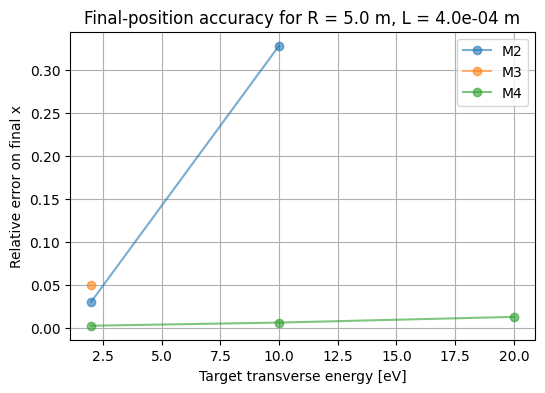

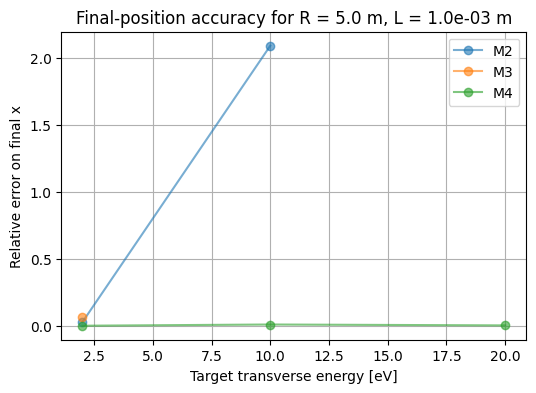

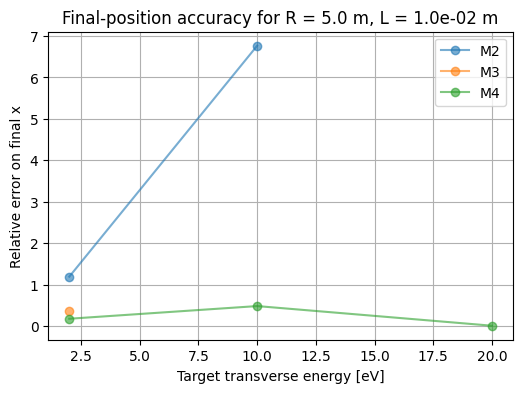

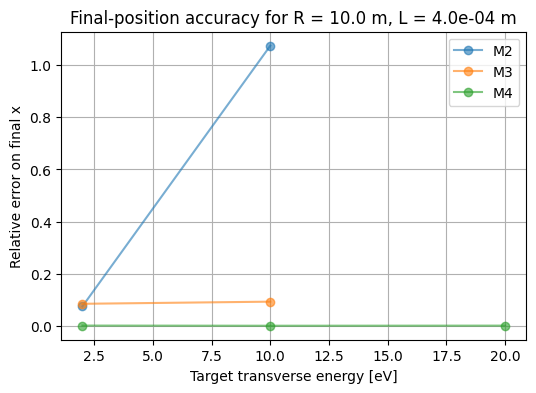

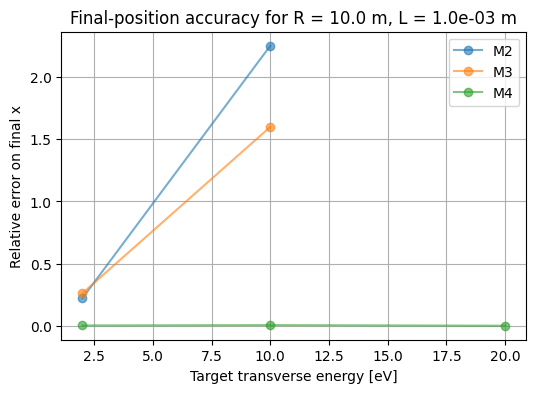

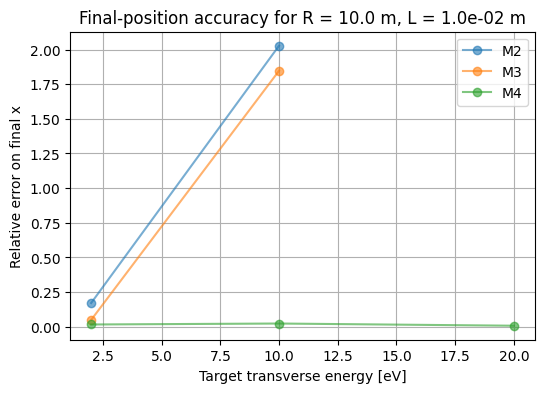

In [33]:
for R_val, L_val in RL_pairs:
    sub = df_all[
        (df_all["R_target_m"] == R_val) &
        (df_all["L_target_m"] == L_val)
    ].copy()

    plt.figure(figsize=(6, 4))

    for method_label in ["M2", "M3", "M4"]:
        sub_m = sub[sub["method_label"] == method_label].sort_values("ET_eV_target")
        plt.plot(
            sub_m["ET_eV_target"],
            sub_m["rel_err_x"],
            marker="o",
            label=method_label,
            alpha=0.6 
        )

    plt.xlabel("Target transverse energy [eV]")
    plt.ylabel("Relative error on final x")
    plt.title(f"Final-position accuracy for R = {R_val:.1f} m, L = {L_val:.1e} m")
    plt.grid(True)
    plt.legend()
    plt.show()

In [89]:
df_ET_summary = (
    df_all.groupby(["ET_eV_target", "method_label"])[
        ["rel_err_x_penalised", "rel_err_px_penalised", "runtime_ms"]
    ]
    .mean()
    .reset_index()
)

df_ET_summary.to_csv("notebook_results/ET_summary.csv", index=False)

df_ET_summary

,ET_eV_target,method_label,rel_err_x_penalised,rel_err_px_penalised,runtime_ms
0,2.0,M2,0.856203,1.113215,0.086811
1,2.0,M3,0.959806,0.934574,0.089374
2,2.0,M4,0.306786,0.641897,1.339340
3,10.0,M2,3334.948671,3333.830070,0.080484
4,10.0,M3,6667.059827,6666.939643,0.067325
5,10.0,M4,0.441854,0.399418,1.456456
6,20.0,M2,10000.000000,10000.000000,0.042544
7,20.0,M3,10000.000000,10000.000000,0.047196
8,20.0,M4,0.156627,1.247014,1.463206


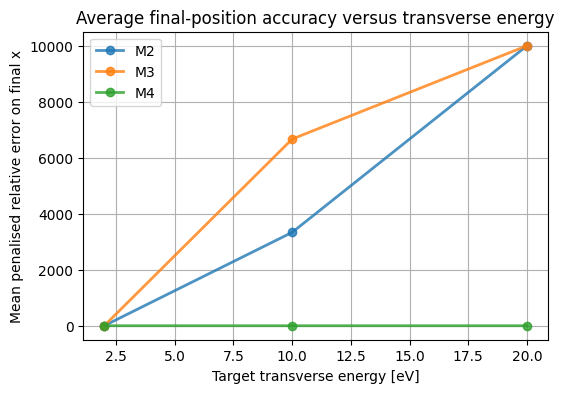

In [83]:
plt.figure(figsize=(6, 4))

for method in ["M2", "M3", "M4"]:
    sub = df_ET_summary[df_ET_summary["method_label"] == method].sort_values("ET_eV_target")

    plt.plot(
        sub["ET_eV_target"],
        sub["rel_err_x_penalised"],
        marker="o",
        linewidth=2,
        alpha=0.8,
        label=method
    )

plt.xlabel("Target transverse energy [eV]")
plt.ylabel("Mean penalised relative error on final x")
plt.title("Average final-position accuracy versus transverse energy")
plt.grid(True)
plt.legend()
plt.show()

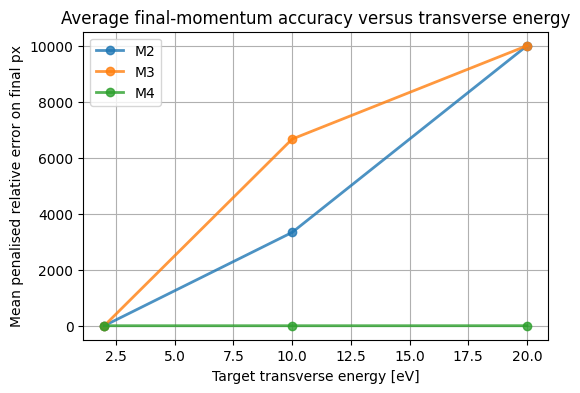

In [84]:
plt.figure(figsize=(6, 4))

for method in ["M2", "M3", "M4"]:
    sub = df_ET_summary[df_ET_summary["method_label"] == method].sort_values("ET_eV_target")

    plt.plot(
        sub["ET_eV_target"],
        sub["rel_err_px_penalised"],
        marker="o",
        linewidth=2,
        alpha=0.8,
        label=method
    )

plt.xlabel("Target transverse energy [eV]")
plt.ylabel("Mean penalised relative error on final px")
plt.title("Average final-momentum accuracy versus transverse energy")
plt.grid(True)
plt.legend()
plt.show()

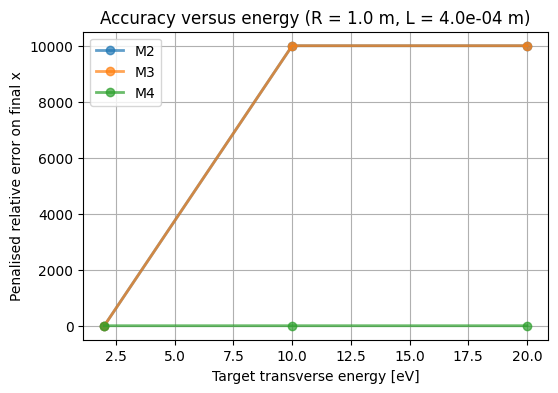

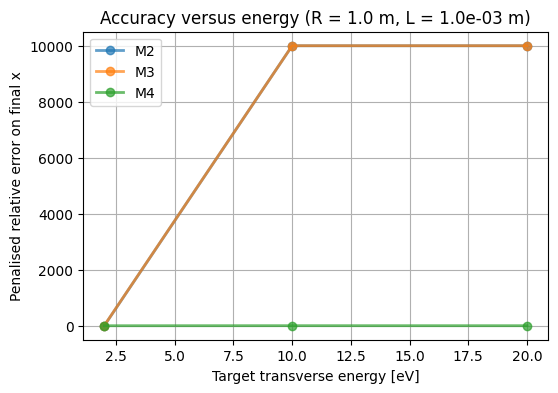

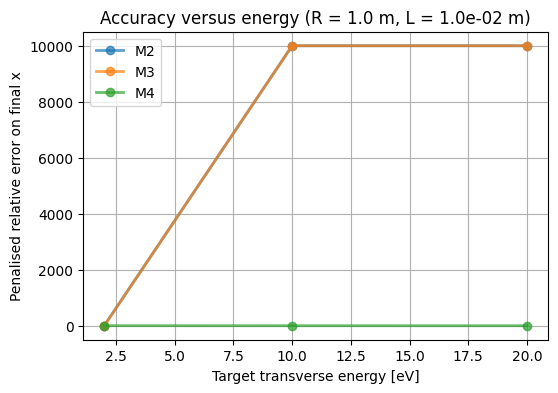

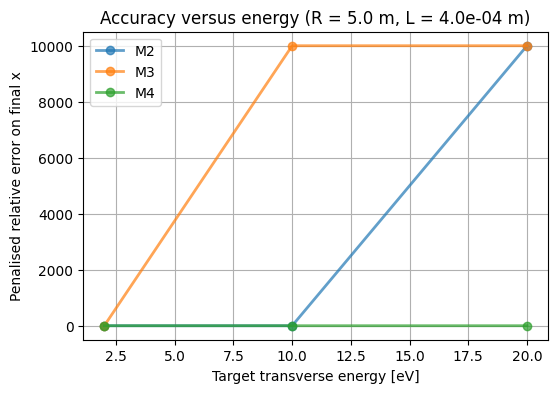

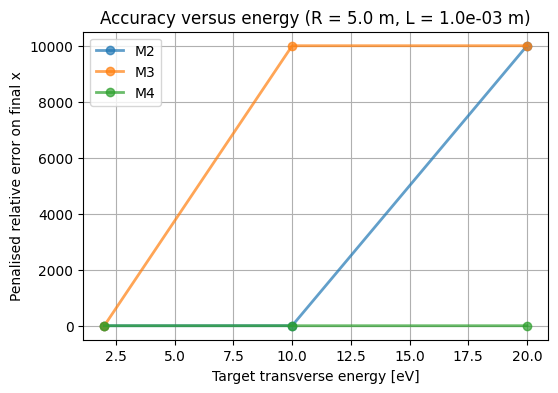

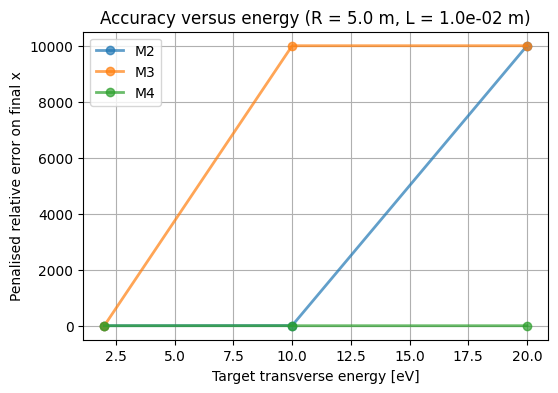

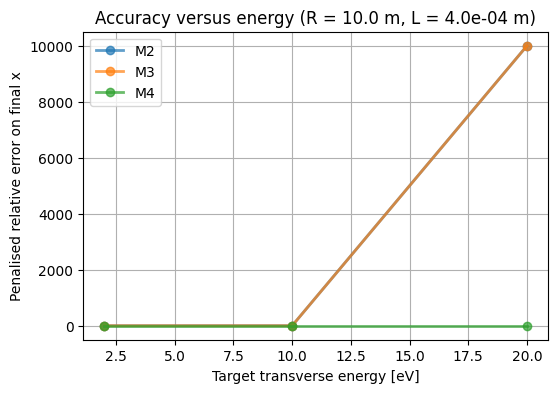

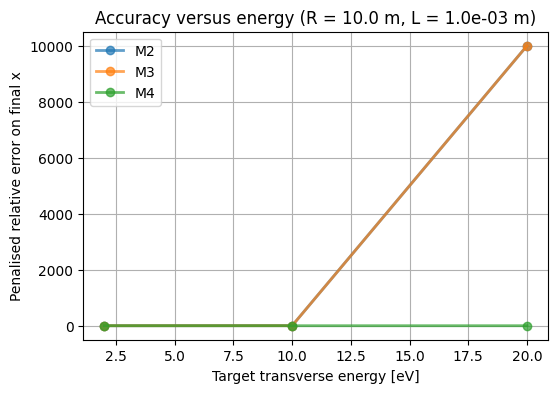

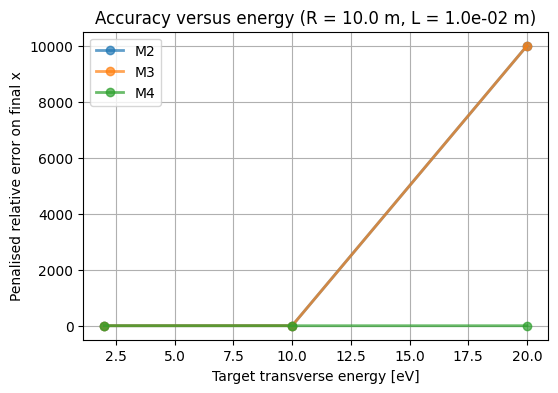

In [85]:
RL_pairs = (
    df_all[["R_target_m", "L_target_m"]]
    .drop_duplicates()
    .sort_values(["R_target_m", "L_target_m"])
    .values
)

for R_val, L_val in RL_pairs:
    sub = df_all[
        (df_all["R_target_m"] == R_val) &
        (df_all["L_target_m"] == L_val)
    ].copy()

    plt.figure(figsize=(6, 4))

    for method in ["M2", "M3", "M4"]:
        sub_m = sub[sub["method_label"] == method].sort_values("ET_eV_target")

        plt.plot(
            sub_m["ET_eV_target"],
            sub_m["rel_err_x_penalised"],
            marker="o",
            linewidth=2,
            alpha=0.7,
            label=method
        )

    plt.xlabel("Target transverse energy [eV]")
    plt.ylabel("Penalised relative error on final x")
    plt.title(f"Accuracy versus energy (R = {R_val:.1f} m, L = {L_val:.1e} m)")
    plt.grid(True)
    plt.legend()
    plt.show()

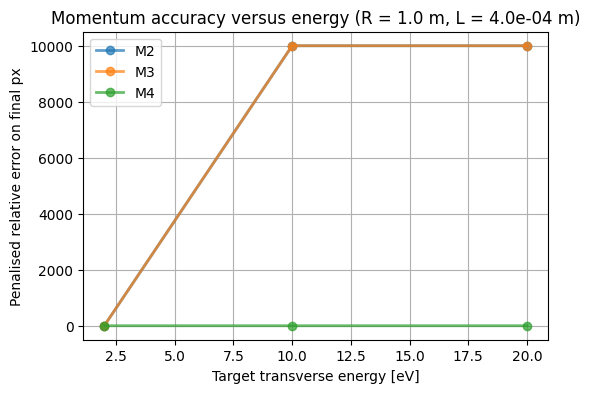

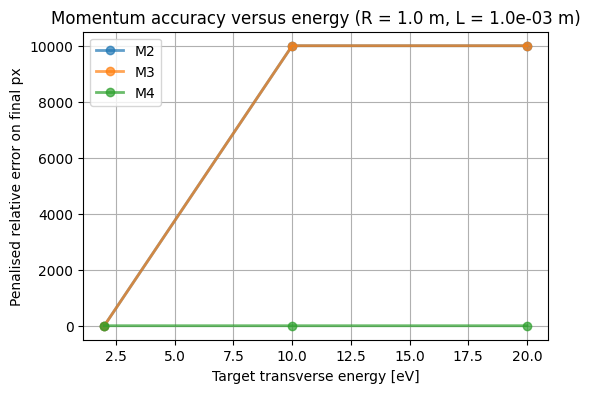

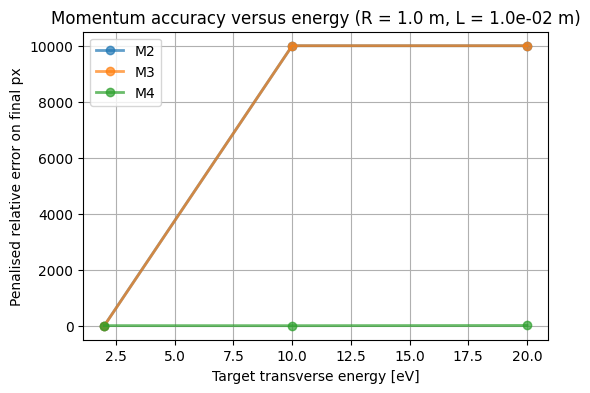

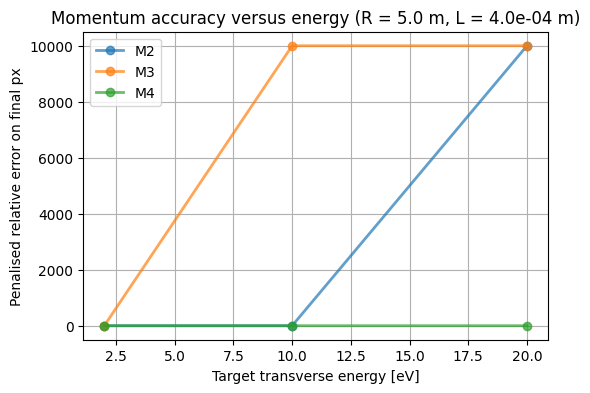

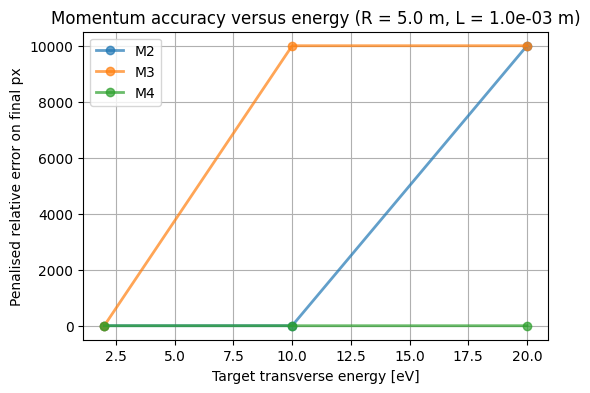

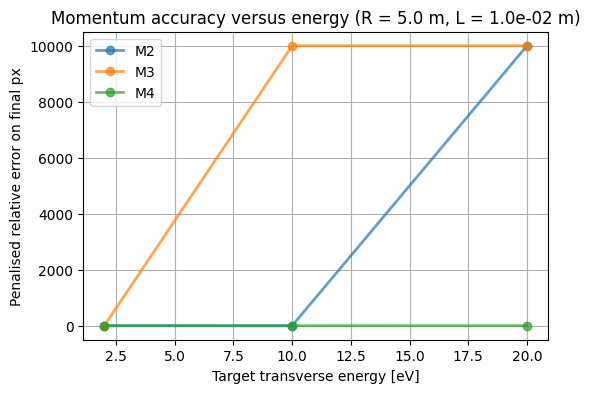

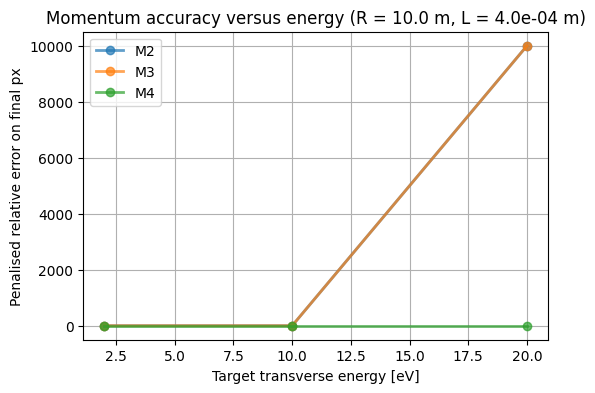

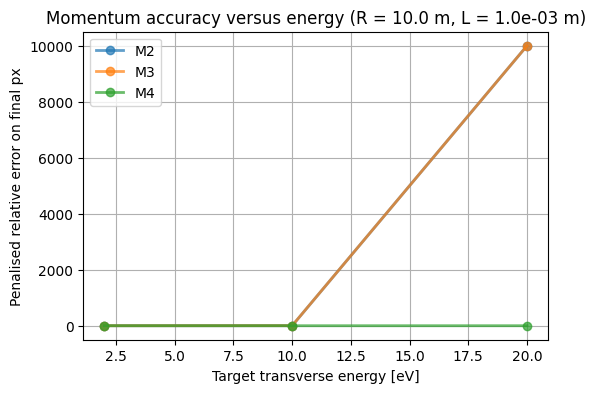

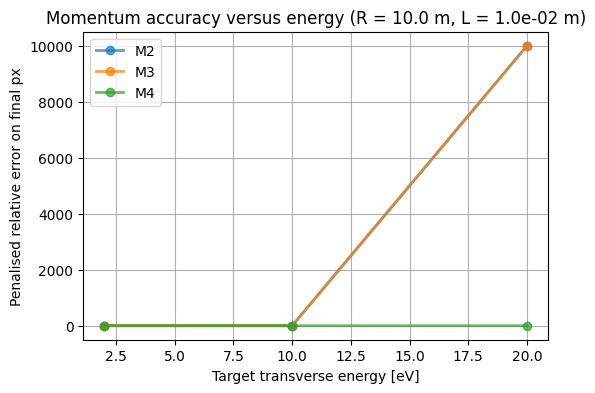

In [86]:
for R_val, L_val in RL_pairs:
    sub = df_all[
        (df_all["R_target_m"] == R_val) &
        (df_all["L_target_m"] == L_val)
    ].copy()

    plt.figure(figsize=(6, 4))

    for method in ["M2", "M3", "M4"]:
        sub_m = sub[sub["method_label"] == method].sort_values("ET_eV_target")

        plt.plot(
            sub_m["ET_eV_target"],
            sub_m["rel_err_px_penalised"],
            marker="o",
            linewidth=2,
            alpha=0.7,
            label=method
        )

    plt.xlabel("Target transverse energy [eV]")
    plt.ylabel("Penalised relative error on final px")
    plt.title(f"Momentum accuracy versus energy (R = {R_val:.1f} m, L = {L_val:.1e} m)")
    plt.grid(True)
    plt.legend()
    plt.show()

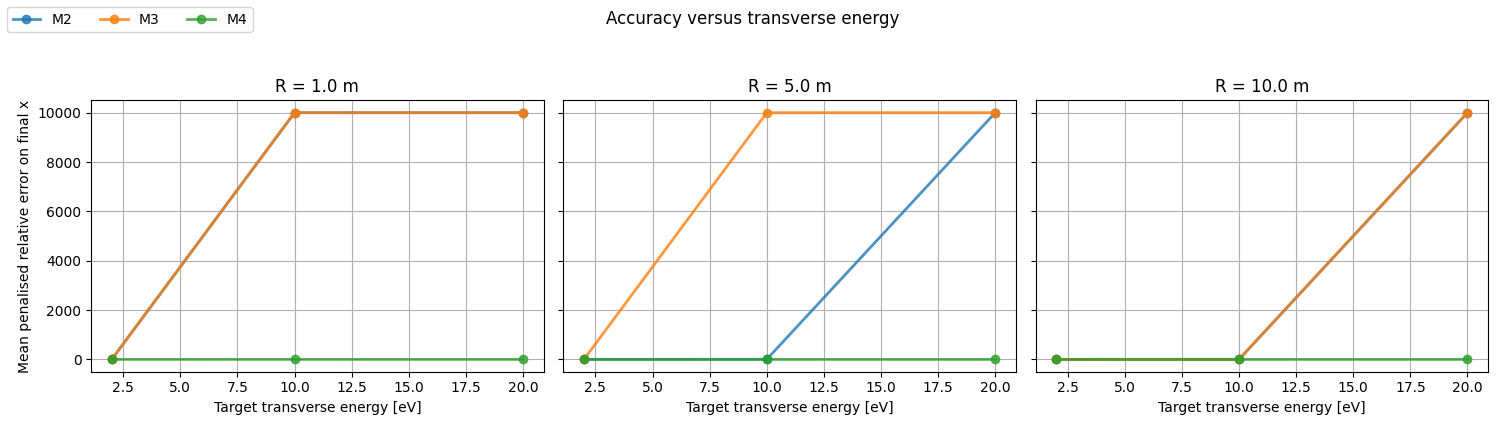

In [88]:
R_values = sorted(df_all["R_target_m"].unique())

fig, axes = plt.subplots(1, len(R_values), figsize=(5 * len(R_values), 4), sharey=True)

if len(R_values) == 1:
    axes = [axes]

for ax, R_val in zip(axes, R_values):
    subR = df_all[df_all["R_target_m"] == R_val]

    for method in ["M2", "M3", "M4"]:
        sub_m = (
            subR[subR["method_label"] == method]
            .groupby("ET_eV_target")["rel_err_x_penalised"]
            .mean()
            .reset_index()
            .sort_values("ET_eV_target")
        )

        ax.plot(
            sub_m["ET_eV_target"],
            sub_m["rel_err_x_penalised"],
            marker="o",
            linewidth=2,
            alpha=0.8,
            label=method
        )

    ax.set_xlabel("Target transverse energy [eV]")
    ax.set_title(f"R = {R_val:.1f} m")
    ax.grid(True)

axes[0].set_ylabel("Mean penalised relative error on final x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=3)

fig.suptitle("Accuracy versus transverse energy", y=1.05)
fig.tight_layout()
plt.show()

In [90]:
pivot_runtime = df_ET_summary.pivot_table(
    index="ET_eV_target",
    columns="method_label",
    values="runtime_ms"
)

pivot_runtime.to_csv("notebook_results/ET_runtime_pivot.csv")

pivot_runtime

method_label,M2,M3,M4
ET_eV_target,,,
2.0,0.086811,0.089374,1.339340
10.0,0.080484,0.067325,1.456456
20.0,0.042544,0.047196,1.463206


## Possible element extensions

The present implementation of `BentChannellingDev` is intended as a development prototype and several extensions are possible.

First, the crystal material is currently not selected explicitly by the user. The element is initialised with parameters corresponding to **Silicon (110)**, but a future implementation could introduce a material abstraction allowing different crystal materials and orientations to be selected automatically.

Second, the bending radius `R` is assumed to be constant along the crystal. A more general model could allow spatially varying curvature or segmented crystals with different bending radii.

From the physics point of view, the current model describes deterministic channelled motion in the continuum potential. Additional interaction mechanisms that could be incorporated include:

- dechanneling due to incoherent scattering,
- volume reflection,
- volume capture,
- nuclear and electronic scattering processes.

Finally, the automatic step-selection procedure currently relies on a harmonic estimate of the oscillation frequency. This approach could be refined by introducing model-dependent criteria better suited to strongly nonlinear potentials such as the Simplified Molière potential.